# TOC
### 1. [Introduction](#introduction)  

### 2. [Data Loading and Preprocessing](#data-loading-and-preprocessing)  
#### [Loading Data]
#### Preprocessing

### 3. [EDA](#exploratory-data-analysis)
#### [Statistical Summary](#statistical-summary)
#### [Visualization](#visualization)

### 4. [Feature Selection or Manipulation](#Feature-Selection)
#### [Correlation Analysis](#correlation-analysis)
#### [Manipulation](#Manipulation)
#### [Feature Importance](#feature-importance)


### 5. [Model Training](#model-training)  
#### [Train-Test Split](#Train-Test-Split)
#### [Normalization/Scaling](#normalizationscaling)
#### [Model Selection](#model-selection)


### 6. [Model Evaluation](#model-evaluation)  
#### [Performance Metrics](#performance-metrics) 
#### [Error Analysis](#error-analysis)
#### [CV](#CV)
#### [Optimization](#)


### 7. [SHAP](#shap-analysis)  
#### [Global SHAP Analysis](#Global-SHAP-Analysis)
#### [Local SHAP Analysis](#Local-SHAP-Analysis)
### 8. [Conclusion](#conclusion)
### 9. [References](#references)

<a id="introduction"></a>
# Introduction

In [1]:
# Ensuring the notebook reloads modules automatically
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Evaluation libraries
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

# Data visualization libraries
import seaborn as sns

#Interpretability libraries
import shap
from sklearn.inspection import PartialDependenceDisplay

<a id="Data-Loading-and-Preprocessing"></a>
# Data Loading and Preprocessing

#Loading data
<a id="Loading-Data"></a>

In [3]:
data = pd.read_csv('GPCACID_DATASET_Cleaner.csv')
print("Data loaded successfully.")
data

Data loaded successfully.


,Fly Ash (g),MK (g),H3PO4 (M),CA(H2PO4) (M),KH2PO4 (M),ADP (M),Monoaluminum Phosphate (MAP) (M),Sodium Dihydrogen Phosphate (SDP) (M),Extra Water (g),L/S,Al/P Ratio,P/A Ratio,Si/P Ratio,P/Si Ratio,Initial pH,"Curing Time, d","Precalcination Temperature,","Curing Temperature, C","Testing age, d",Compressive Strength_MPa
0,0,1416.67,6.00,0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.00,0.0,0.0,1,0,50,28,19.81
1,0,1416.67,6.00,0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.00,0.0,0.0,1,0,24,28,20.54
2,0,1416.67,8.00,0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.00,0.0,0.0,1,0,50,28,8.34
3,0,1416.67,8.00,0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.00,0.0,0.0,1,0,24,28,8.03
4,0,1416.67,0.00,4,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.00,0.0,0.0,1,0,50,28,4.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,0,500.00,17.19,0,0.0,0.0,0.0,0.0,0.0,3.4,0.0,0.0,2.00,0.0,0.0,1,700,60,28,5.30
139,0,444.44,17.19,0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,0.0,2.25,0.0,0.0,1,700,60,28,6.60
140,0,400.00,17.19,0,0.0,0.0,0.0,0.0,0.0,4.2,0.0,0.0,2.50,0.0,0.0,1,700,60,28,5.75
141,0,363.64,17.19,0,0.0,0.0,0.0,0.0,0.0,4.6,0.0,0.0,2.75,0.0,0.0,1,700,60,28,4.49


<a id="Preprocessing"></a>
#Data preprocessing  

In [4]:
# Get a list of all columns in the DataFrame
#all_columns = list(data.columns)
# Prompt user to select features and target variable interactively
#print("Available columns:")
#for i, col in enumerate(all_columns):
#    print(f"{i+1}. {col}")

In [5]:
# Prompt user to select features and target variable interactively
#feature_input = input("Enter comma-separated indices of the features you want to use (e.g., 1,2,3): ")
#feature_indices = [int(x) - 1 for x in feature_input.split(',')]  # Adjust for 0-based indexing
#target_index = int(input("Enter the index of the target variable (from the list above): ")) - 1  # Adjust for 0-based indexing

# Extract features and target variable based on user input
target = 'Compressive Strength_MPa'
features = [col for col in data.columns if col != target]


# Print confirmation message
print(f"\nSelected features: {features}") #enter 1,2,3,4,5,6,7,8,9*,10,18,19
print(f"Target variable: {target}") #enter 20


Selected features: ['Fly Ash (g)', 'MK (g)', 'H3PO4 (M)', 'CA(H2PO4) (M)', 'KH2PO4 (M)', 'ADP (M)', 'Monoaluminum Phosphate (MAP) (M)', 'Sodium Dihydrogen Phosphate (SDP) (M)', 'Extra Water (g)', 'L/S', 'Al/P Ratio', 'P/A Ratio', 'Si/P Ratio', 'P/Si Ratio', 'Initial pH', 'Curing Time, d', 'Precalcination Temperature,', 'Curing Temperature, C', 'Testing age, d']
Target variable: Compressive Strength_MPa


<a id="Exploratory Data Analysis"></a>
# Exploratory Data Analysis

<a id="Statistical-Summary"></a>
Data Description

In [6]:
# Identify features (mix design variables) and target variable (mechanical property)
features_final = features
target_final = target

# Create a new DataFrame with selected features and target variable
database = data[features_final + [target_final]]

print("Data Description:")
print(database.describe())

Data Description:
       Fly Ash (g)       MK (g)   H3PO4 (M)  CA(H2PO4) (M)  KH2PO4 (M)  \
count   143.000000   143.000000  143.000000     143.000000  143.000000   
mean    735.664336   351.250699    6.959510       0.139860    1.031049   
std    1153.760270   544.650173    7.208885       0.844213    3.974568   
min       0.000000     0.000000    0.000000       0.000000    0.000000   
25%       0.000000     0.000000    0.000000       0.000000    0.000000   
50%       0.000000   100.000000    6.000000       0.000000    0.000000   
75%    1980.000000   422.220000   14.610000       0.000000    0.000000   
max    3150.000000  1494.720000   17.190000       6.000000   17.180000   

          ADP (M)  Monoaluminum Phosphate (MAP) (M)  \
count  143.000000                        143.000000   
mean     0.683566                          0.156643   
std      1.283102                          0.645740   
min      0.000000                          0.000000   
25%      0.000000                       

<a id="Visualization"></a>
Database Plots

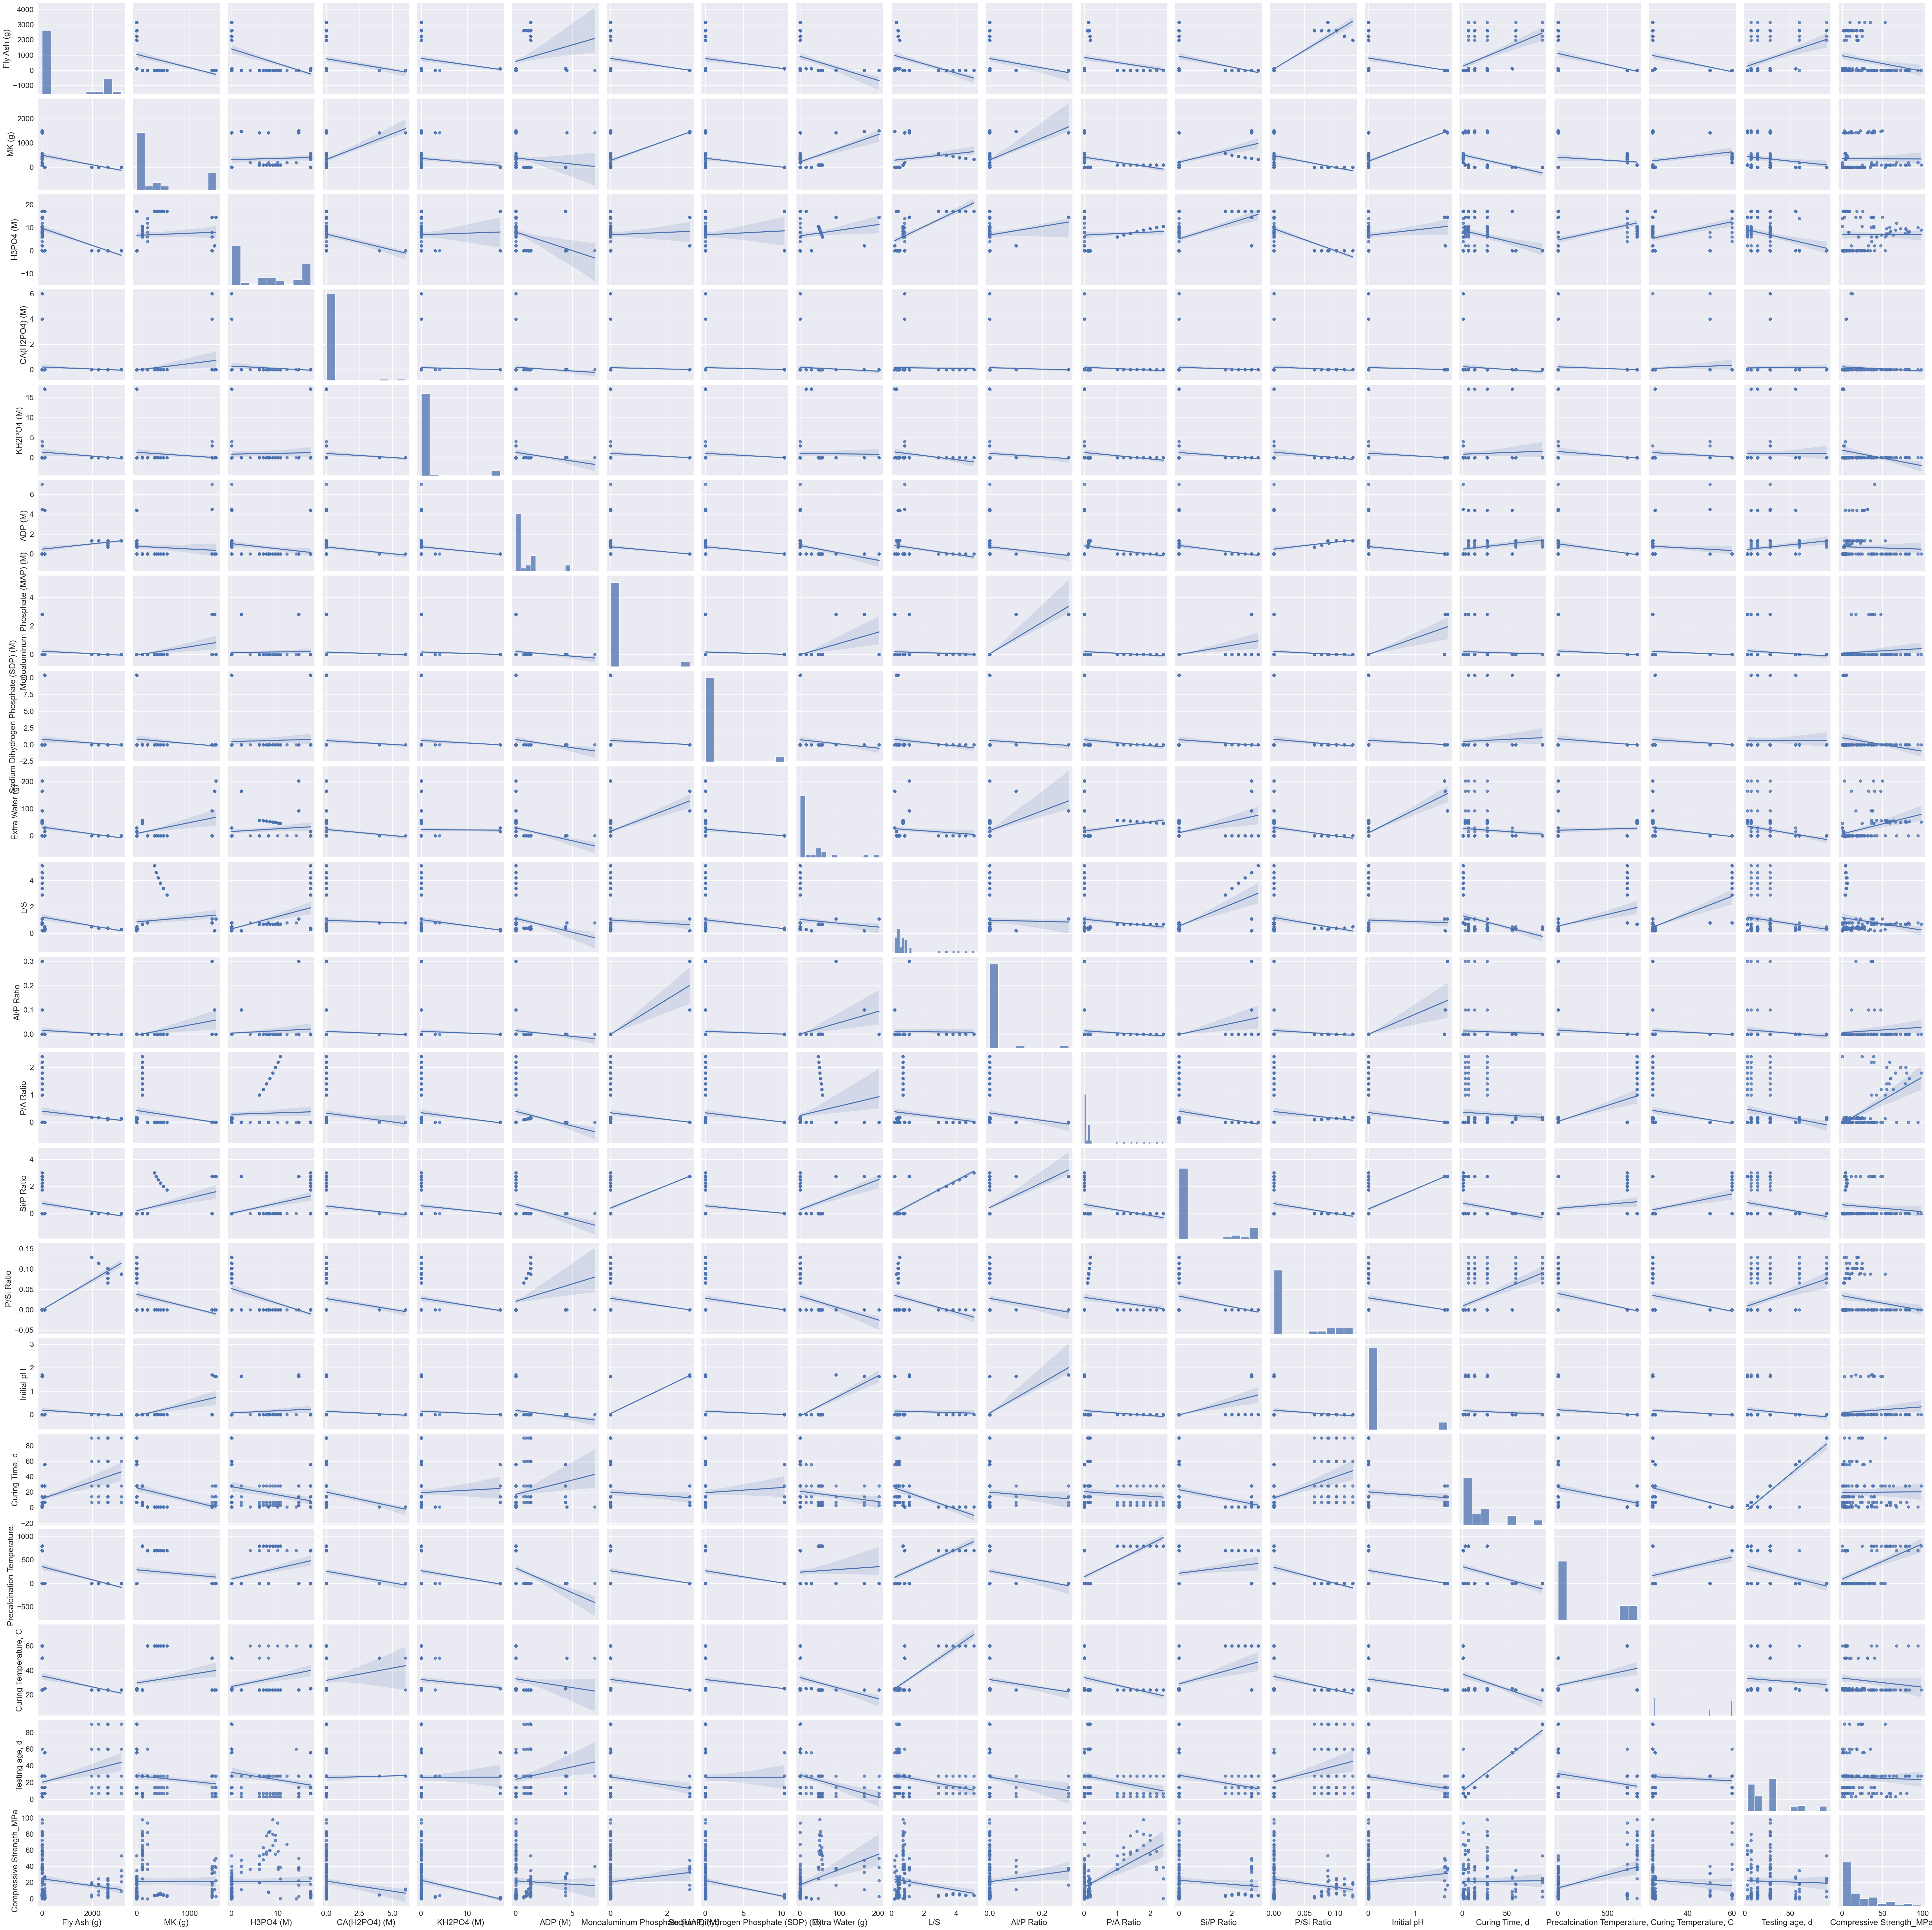

In [7]:
# Pairplot to visualize relationships
sns.set(font_scale=1.5)
relation = sns.pairplot(database, kind="reg", height=3)

<a id="Feature Selection"></a>
# Feature Selection or Manipulation

<a id="Correlation-Analysis"></a>
Your correlation analysis content goes here.  

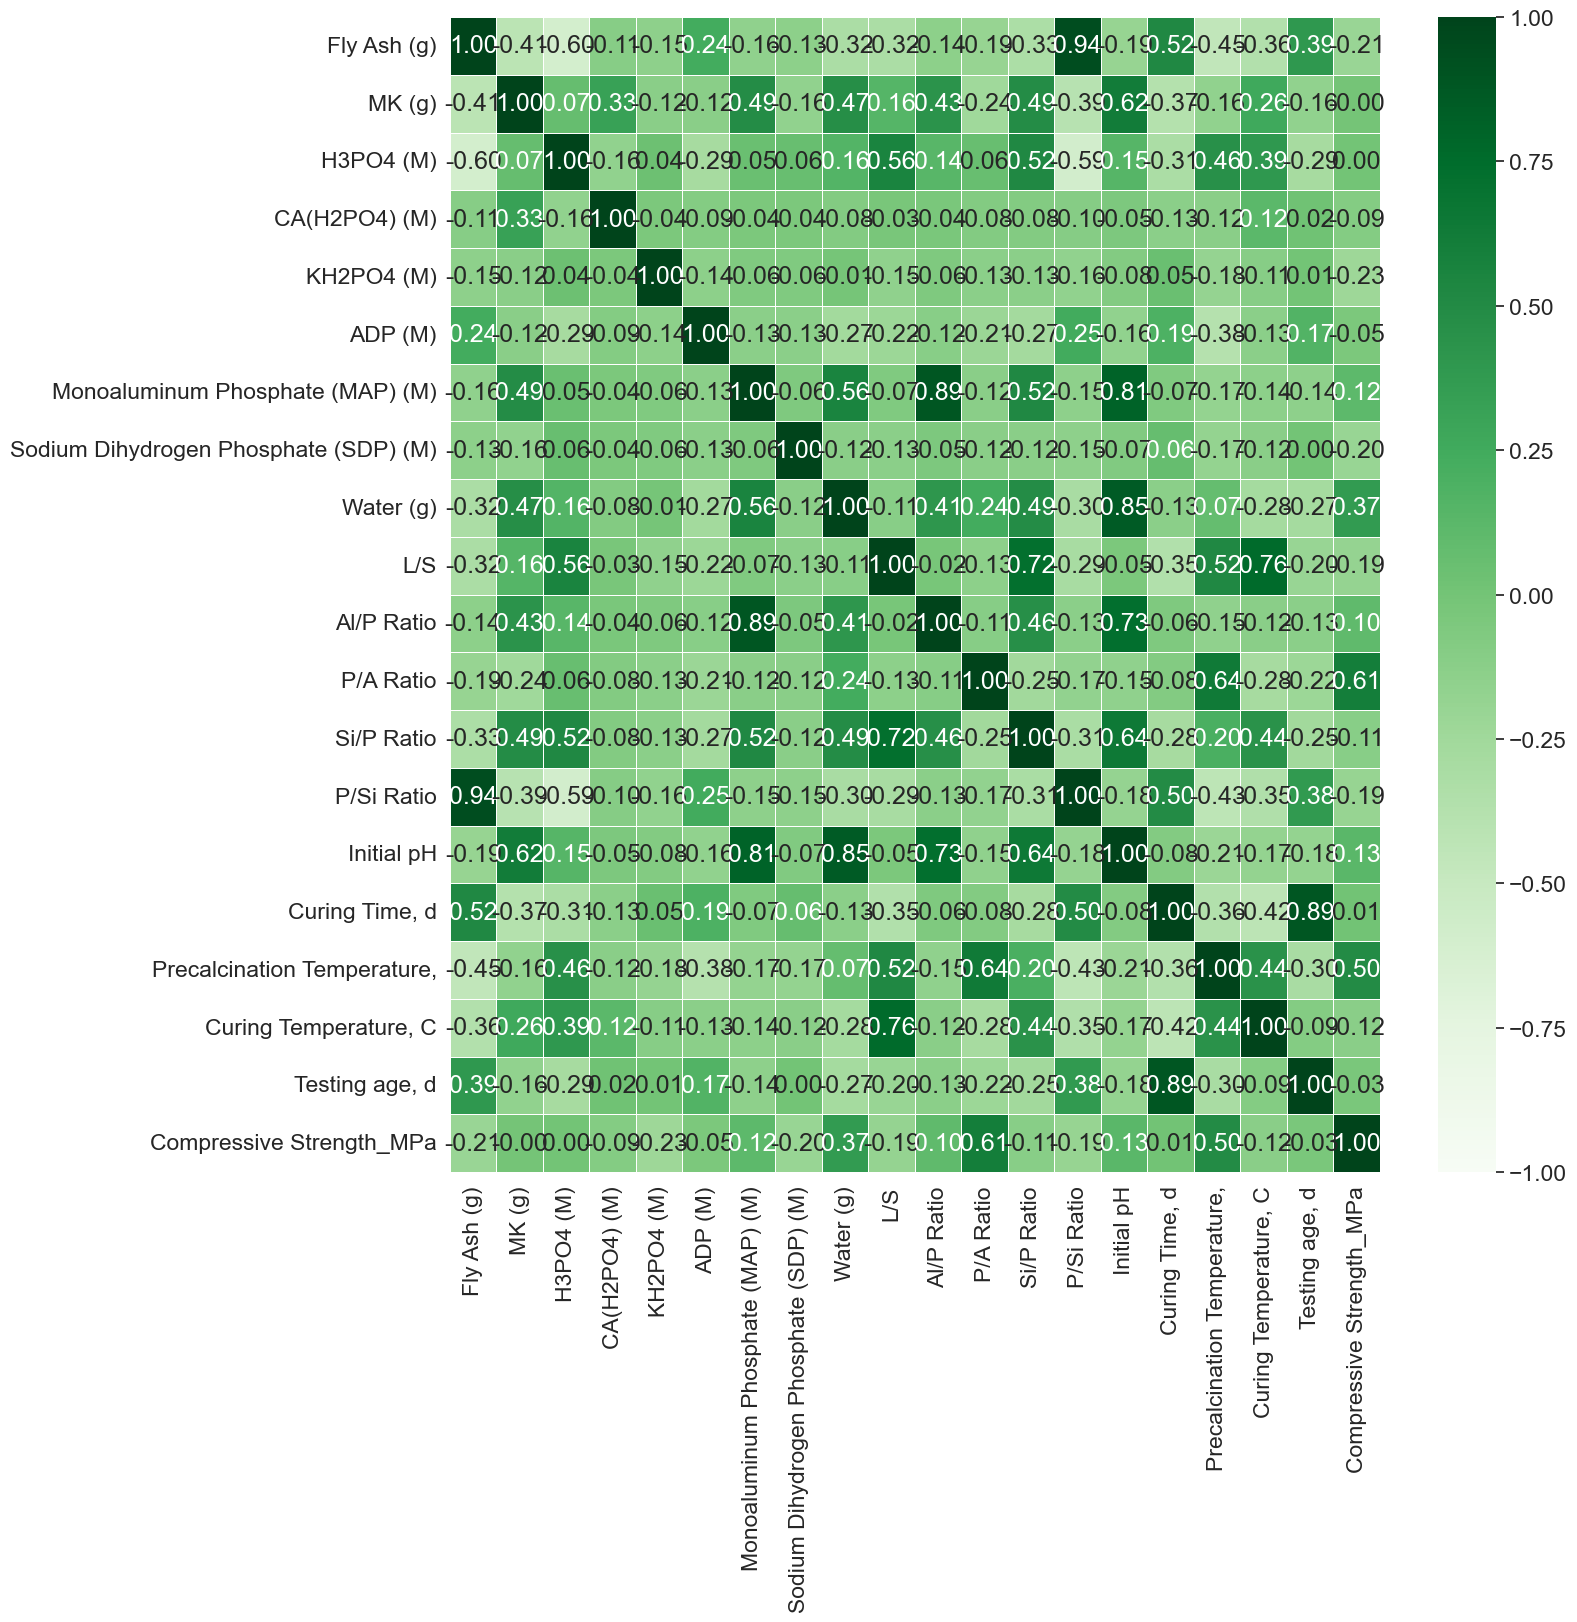

In [8]:
# Calculate correlation matrix
correlation_matrix = database.corr()

# Heatmap to visualize correlations
plt.figure(figsize=(15, 15))
heatmap = sns.heatmap(
    correlation_matrix, 
    cmap="Greens", 
    annot=True, 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    linecolor='white'
)
plt.show()

<a id="Manipulation"></a>
Data Manipulation for missing values etc

In [8]:
#Check for missing data and handle appropriately (e.g., imputation or removal)
print("Missing data per column:")
print(data.isnull().sum())

# Optionally, handle missing data if any
# data.fillna(method='ffill', inplace=True)

Missing data per column:
Fly Ash (g)                              0
MK (g)                                   0
H3PO4 (M)                                0
CA(H2PO4) (M)                            0
KH2PO4 (M)                               0
ADP (M)                                  0
Monoaluminum Phosphate (MAP) (M)         0
Sodium Dihydrogen Phosphate (SDP) (M)    0
Extra Water (g)                          0
L/S                                      0
Al/P Ratio                               0
P/A Ratio                                0
Si/P Ratio                               0
P/Si Ratio                               0
Initial pH                               0
Curing Time, d                           0
Precalcination Temperature,              0
Curing Temperature, C                    0
Testing age, d                           0
Compressive Strength_MPa                 0
dtype: int64


<a id="Feature-Importance"></a>
Your feature importance content goes here. 

<a id="Model Training"></a>
# Model Training

<a id="Train-Test-Split"></a>
Train-Test Split

In [9]:
# Split data into training and testing sets
X = data[features_final]
y = data[target_final]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="Normalization/Scaling"></a>
Data normalization

In [10]:
# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id="Model-Selection"></a>
Your model selection content goes here.

In [11]:
# Define and train the initial model
initial_model = RandomForestRegressor(n_estimators=100, random_state=42)
initial_model.fit(X_train_scaled, y_train)

# Make predictions on the testing set
y_pred_initial = initial_model.predict(X_test_scaled)

<a id="model-evaluation"></a>
# Model Evaluation

<a id="Performance-Metrics"></a>
Your performance metrics content goes here. 

In [12]:
# Set up cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
# Calculate evaluation metrics
# Define custom scorers
def robust_mape(y_true, y_pred):
    epsilon = 1e-10  # Small value to avoid division by zero
    mask = y_true > epsilon  # Filter out zero or near-zero values
    y_true_filtered = y_true[mask]
    y_pred_filtered = y_pred[mask]
    
    errors = np.abs((y_true_filtered - y_pred_filtered) / (y_true_filtered + epsilon)) * 100
    capped_errors = np.clip(errors, 0, 100)  # Cap the errors to a maximum value
    return np.mean(capped_errors)

rmse_scorer = make_scorer(mean_squared_error, squared=False)
r2_scorer = make_scorer(r2_score)
robust_mape_scorer = make_scorer(robust_mape, greater_is_better=True)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=True)


In [14]:
# Perform cross-validation for all metrics
cv_rmse_scores = cross_val_score(initial_model, X_train_scaled, y_train, cv=kf, scoring=rmse_scorer)
cv_r2_scores = cross_val_score(initial_model, X_train_scaled, y_train, cv=kf, scoring=r2_scorer)
#cv_mape_scores = cross_val_score(initial_model, X_train_scaled, y_train, cv=kf, scoring=mape_scorer)
cv_mae_scores = cross_val_score(initial_model, X_train_scaled, y_train, cv=kf, scoring=mae_scorer)
# Perform cross-validation with robust MAPE
cv_robust_mape_scores = cross_val_score(initial_model, X_train_scaled, y_train, cv=kf, scoring=robust_mape_scorer)

c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

In [15]:
# Print cross-validation results
print("*************** Print CV results *********************")
print("********************* RSME ***************************")
print("Cross-Validation RMSE Scores:", cv_rmse_scores)
print("Mean Cross-Validation RMSE:", np.mean(cv_rmse_scores))
print("Standard Deviation of Cross-Validation RMSE:", np.std(cv_rmse_scores))
print("********************** R2 ****************************")
print("Cross-Validation R² Scores:", cv_r2_scores)
print("Mean Cross-Validation R²:", np.mean(cv_r2_scores))
print("Standard Deviation of Cross-Validation R²:", np.std(cv_r2_scores))
print("*********************** MAPE *************************")
print("Cross-Validation MAPE Scores:", cv_robust_mape_scores)
print("Mean Cross-Validation MAPE:", np.mean(cv_robust_mape_scores))
print("Standard Deviation of Cross-Validation MAPE:", np.std(cv_robust_mape_scores))
print("*********************** MAE **************************")
print("Cross-Validation MAE Scores:", cv_mae_scores)
print("Mean Cross-Validation MAE:", np.mean(cv_mae_scores))
print("Standard Deviation of Cross-Validation MAE:", np.std(cv_mae_scores))

*************** Print CV results *********************
********************* RSME ***************************
Cross-Validation RMSE Scores: [ 7.48367184 10.3748582  12.62092142  5.40475672 10.68267727]
Mean Cross-Validation RMSE: 9.313377088130695
Standard Deviation of Cross-Validation RMSE: 2.5521249620355597
********************** R2 ****************************
Cross-Validation R² Scores: [0.85459878 0.85573804 0.69440626 0.9153052  0.85299556]
Mean Cross-Validation R²: 0.8346087694293288
Standard Deviation of Cross-Validation R²: 0.07396320431879287
*********************** MAPE *************************
Cross-Validation MAPE Scores: [36.92786974 26.45390541 37.59300704 41.51337653 29.90958762]
Mean Cross-Validation MAPE: 34.47954926947844
Standard Deviation of Cross-Validation MAPE: 5.485583415887847
*********************** MAE **************************
Cross-Validation MAE Scores: [5.78071739 6.58936739 7.67659855 3.94495652 5.3709072 ]
Mean Cross-Validation MAE: 5.87250941040843

<a id="Error-Analysis"></a>
Your error analysis content goes here.

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
# Initialize the model
initial_model = RandomForestRegressor(random_state=42)

# Set up Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=initial_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

# Perform the grid search on the training data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score (R2):", best_score)




Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Score (R2): 0.8385541568537398


Optimized Model Evaluation:
RMSE: 10.370
R-squared: 0.725
MAE: 4.690
MAPE: 31.284
Optimized Model Training Evaluation:
RMSE: 3.245
R-squared: 0.982
MAE: 1.912
MAPE: 15.082


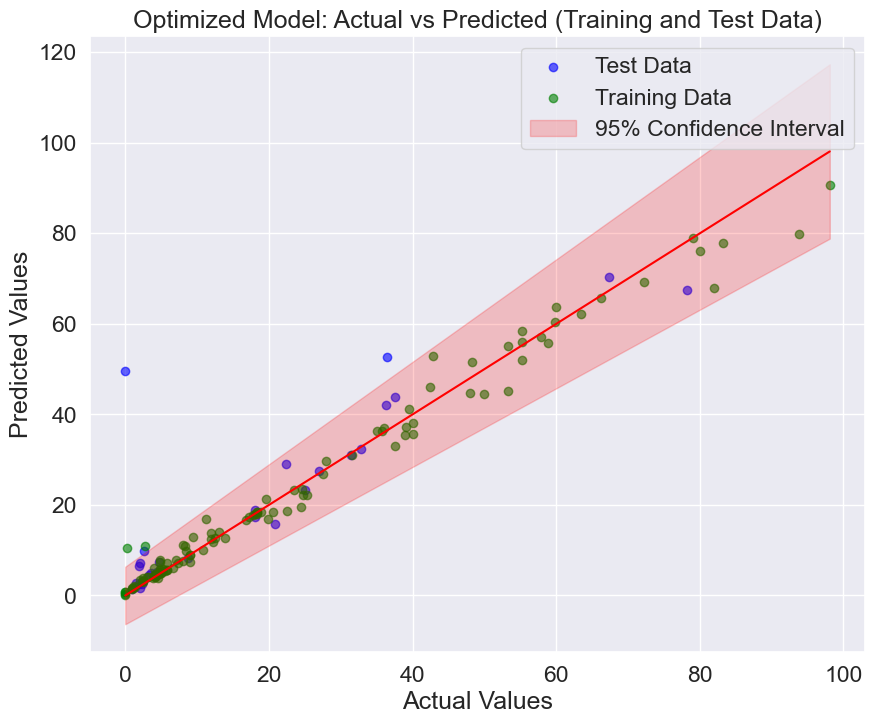

In [30]:
# Train the optimized model on the full training data
optimized_model = RandomForestRegressor(**best_params, random_state=42)
optimized_model.fit(X_train_scaled, y_train)

# Evaluate the optimized model on the test data
y_pred_optimized = optimized_model.predict(X_test_scaled)

# Calculate evaluation metrics for the optimized model
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
mape_optimized = robust_mape(y_test, y_pred_optimized)

print("Optimized Model Evaluation:")
print(f"RMSE: {rmse_optimized:.3f}")
print(f"R-squared: {r2_optimized:.3f}")
print(f"MAE: {mae_optimized:.3f}")
print(f"MAPE: {mape_optimized:.3f}")

# Evaluate the optimized model on the training data
y_pred_train_optimized = optimized_model.predict(X_train_scaled)

# Calculate evaluation metrics for the optimized model on training data
mse_train_optimized = mean_squared_error(y_train, y_pred_train_optimized)
rmse_train_optimized = np.sqrt(mse_train_optimized)
r2_train_optimized = r2_score(y_train, y_pred_train_optimized)
mae_train_optimized = mean_absolute_error(y_train, y_pred_train_optimized)
mape_train_optimized = robust_mape(y_train, y_pred_train_optimized)

print("Optimized Model Training Evaluation:")
print(f"RMSE: {rmse_train_optimized:.3f}")
print(f"R-squared: {r2_train_optimized:.3f}")
print(f"MAE: {mae_train_optimized:.3f}")
print(f"MAPE: {mape_train_optimized:.3f}")

# Plot actual vs predicted with fitted line for the optimized model on both test and training data
plt.figure(figsize=(10, 8))

# Scatter plot for test data
plt.scatter(y_test, y_pred_optimized, color='blue', label='Test Data', alpha=0.6)
# Scatter plot for training data
plt.scatter(y_train, y_pred_train_optimized, color='green', label='Training Data', alpha=0.6)

# Fitted line
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], color='red')

# Confidence interval (for example, using a 95% confidence interval)
z = 1.96  # z-score for 95% confidence
y_train_pred_std = np.std(y_pred_train_optimized - y_train)
y_test_pred_std = np.std(y_pred_optimized - y_test)

plt.fill_between(
    [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
    [min(y_train.min(), y_test.min()) - z * y_train_pred_std, max(y_train.max(), y_test.max()) - z * y_test_pred_std],
    [min(y_train.min(), y_test.min()) + z * y_train_pred_std, max(y_train.max(), y_test.max()) + z * y_test_pred_std],
    color='red', alpha=0.2, label='95% Confidence Interval'
)

plt.title('Optimized Model: Actual vs Predicted (Training and Test Data)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

# Define a more refined parameter grid based on initial results
param_grid_refined = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 3, 4, 5, 6],
    'min_samples_leaf': [1, 2, 3, 4],
    'bootstrap': [True, False]
}

# Initialize the model
initial_model = RandomForestRegressor(random_state=42)

# Set up refined Grid Search with Cross-Validation
grid_search_refined = GridSearchCV(estimator=initial_model, param_grid=param_grid_refined, cv=5, scoring='r2', n_jobs=-1, verbose=2)

# Perform the refined grid search on the training data
grid_search_refined.fit(X_train_scaled, y_train)

# Get the best parameters and the best score from the refined search
best_params_refined = grid_search_refined.best_params_
best_score_refined = grid_search_refined.best_score_

print("Refined Best Parameters:", best_params_refined)
print("Refined Best Cross-Validation Score (R2):", best_score_refined)


Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Refined Best Parameters: {'bootstrap': True, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Refined Best Cross-Validation Score (R2): 0.8385818525308537


Refined Optimized Model Evaluation:
RMSE: 10.365
R-squared: 0.726
MAE: 4.689
MAPE: 31.296
Refined Optimized Model Training Evaluation:
RMSE: 3.245
R-squared: 0.982
MAE: 1.913
MAPE: 15.104


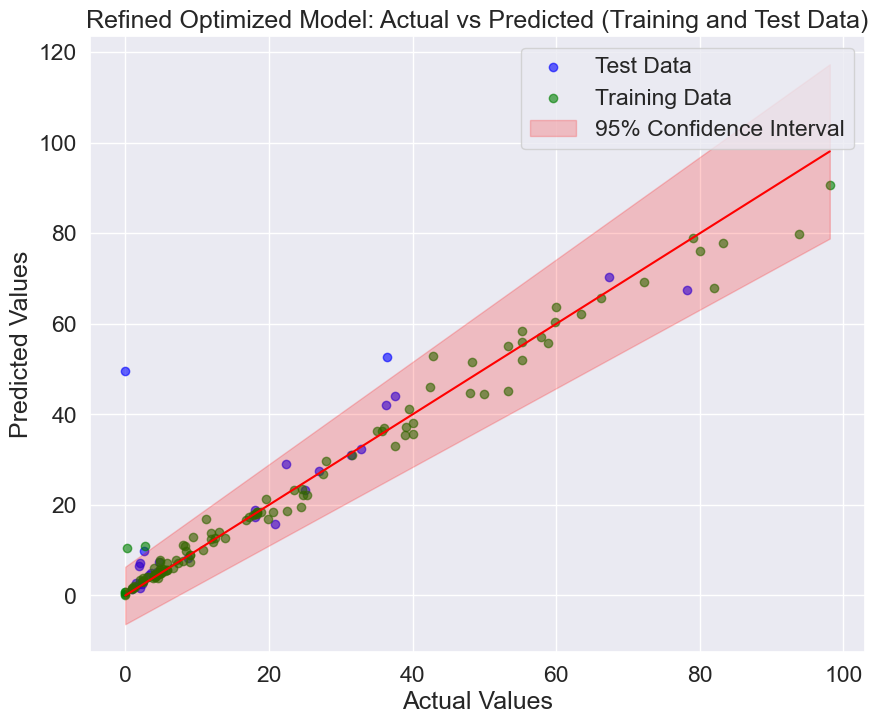

In [31]:
# Train the optimized model with refined parameters on the full training data
optimized_model_refined = RandomForestRegressor(**best_params_refined, random_state=42)
optimized_model_refined.fit(X_train_scaled, y_train)

# Evaluate the optimized model with refined parameters on the test data
y_pred_optimized_refined = optimized_model_refined.predict(X_test_scaled)

# Calculate evaluation metrics for the refined optimized model
mse_optimized_refined = mean_squared_error(y_test, y_pred_optimized_refined)
rmse_optimized_refined = np.sqrt(mse_optimized_refined)
r2_optimized_refined = r2_score(y_test, y_pred_optimized_refined)
mae_optimized_refined = mean_absolute_error(y_test, y_pred_optimized_refined)
mape_optimized_refined = robust_mape(y_test, y_pred_optimized_refined)

print("Refined Optimized Model Evaluation:")
print(f"RMSE: {rmse_optimized_refined:.3f}")
print(f"R-squared: {r2_optimized_refined:.3f}")
print(f"MAE: {mae_optimized_refined:.3f}")
print(f"MAPE: {mape_optimized_refined:.3f}")

# Evaluate the optimized model with refined parameters on the training data
y_pred_train_optimized_refined = optimized_model_refined.predict(X_train_scaled)

# Calculate evaluation metrics for the refined optimized model on training data
mse_train_optimized_refined = mean_squared_error(y_train, y_pred_train_optimized_refined)
rmse_train_optimized_refined = np.sqrt(mse_train_optimized_refined)
r2_train_optimized_refined = r2_score(y_train, y_pred_train_optimized_refined)
mae_train_optimized_refined = mean_absolute_error(y_train, y_pred_train_optimized_refined)
mape_train_optimized_refined = robust_mape(y_train, y_pred_train_optimized_refined)

print("Refined Optimized Model Training Evaluation:")
print(f"RMSE: {rmse_train_optimized_refined:.3f}")
print(f"R-squared: {r2_train_optimized_refined:.3f}")
print(f"MAE: {mae_train_optimized_refined:.3f}")
print(f"MAPE: {mape_train_optimized_refined:.3f}")

# Plot actual vs predicted with fitted line for the refined optimized model on both test and training data
plt.figure(figsize=(10, 8))

# Scatter plot for test data
plt.scatter(y_test, y_pred_optimized_refined, color='blue', label='Test Data', alpha=0.6)
# Scatter plot for training data
plt.scatter(y_train, y_pred_train_optimized_refined, color='green', label='Training Data', alpha=0.6)

# Fitted line
plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], 
         [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())], color='red')

# Confidence interval (for example, using a 95% confidence interval)
z = 1.96  # z-score for 95% confidence
y_train_pred_std = np.std(y_pred_train_optimized_refined - y_train)
y_test_pred_std = np.std(y_pred_optimized_refined - y_test)

plt.fill_between(
    [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
    [min(y_train.min(), y_test.min()) - z * y_train_pred_std, max(y_train.max(), y_test.max()) - z * y_test_pred_std],
    [min(y_train.min(), y_test.min()) + z * y_train_pred_std, max(y_train.max(), y_test.max()) + z * y_test_pred_std],
    color='red', alpha=0.2, label='95% Confidence Interval'
)

plt.title('Refined Optimized Model: Actual vs Predicted (Training and Test Data)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Function to select the best model based on cross-validation R² scores from grid search
def select_best_model_from_grid_search(grid_search_results):
    best_score = -float('inf')
    best_params = None
    
    for result in grid_search_results:
        if result['best_score'] > best_score:
            best_score = result['best_score']
            best_params = result['best_params']
    
    best_model = RandomForestRegressor(**best_params, random_state=42)
    return best_model, best_score

# Define the grid search results
grid_search_results = [
    {
        "best_score": np.mean(cv_r2_scores),
        "best_params": initial_model.get_params()
    },
    {
        "best_score": best_score,
        "best_params": best_params
    },
    {
        "best_score": best_score_refined,
        "best_params": best_params_refined
    }
]

# Select the best model based on cross-validation R² scores
best_model, best_score = select_best_model_from_grid_search(grid_search_results)
print(f"Best model selected based on cross-validation R² score: {best_model}")
print(f"Best cross-validation R² score: {best_score}")

Best model selected based on cross-validation R² score: RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)
Best cross-validation R² score: 0.8385818525308537


<a id="SHAP Analysis"></a>
# SHAP Analysis

<a id="Global-SHAP-Analysis"></a>
Your global SHAP analysis content goes here.  

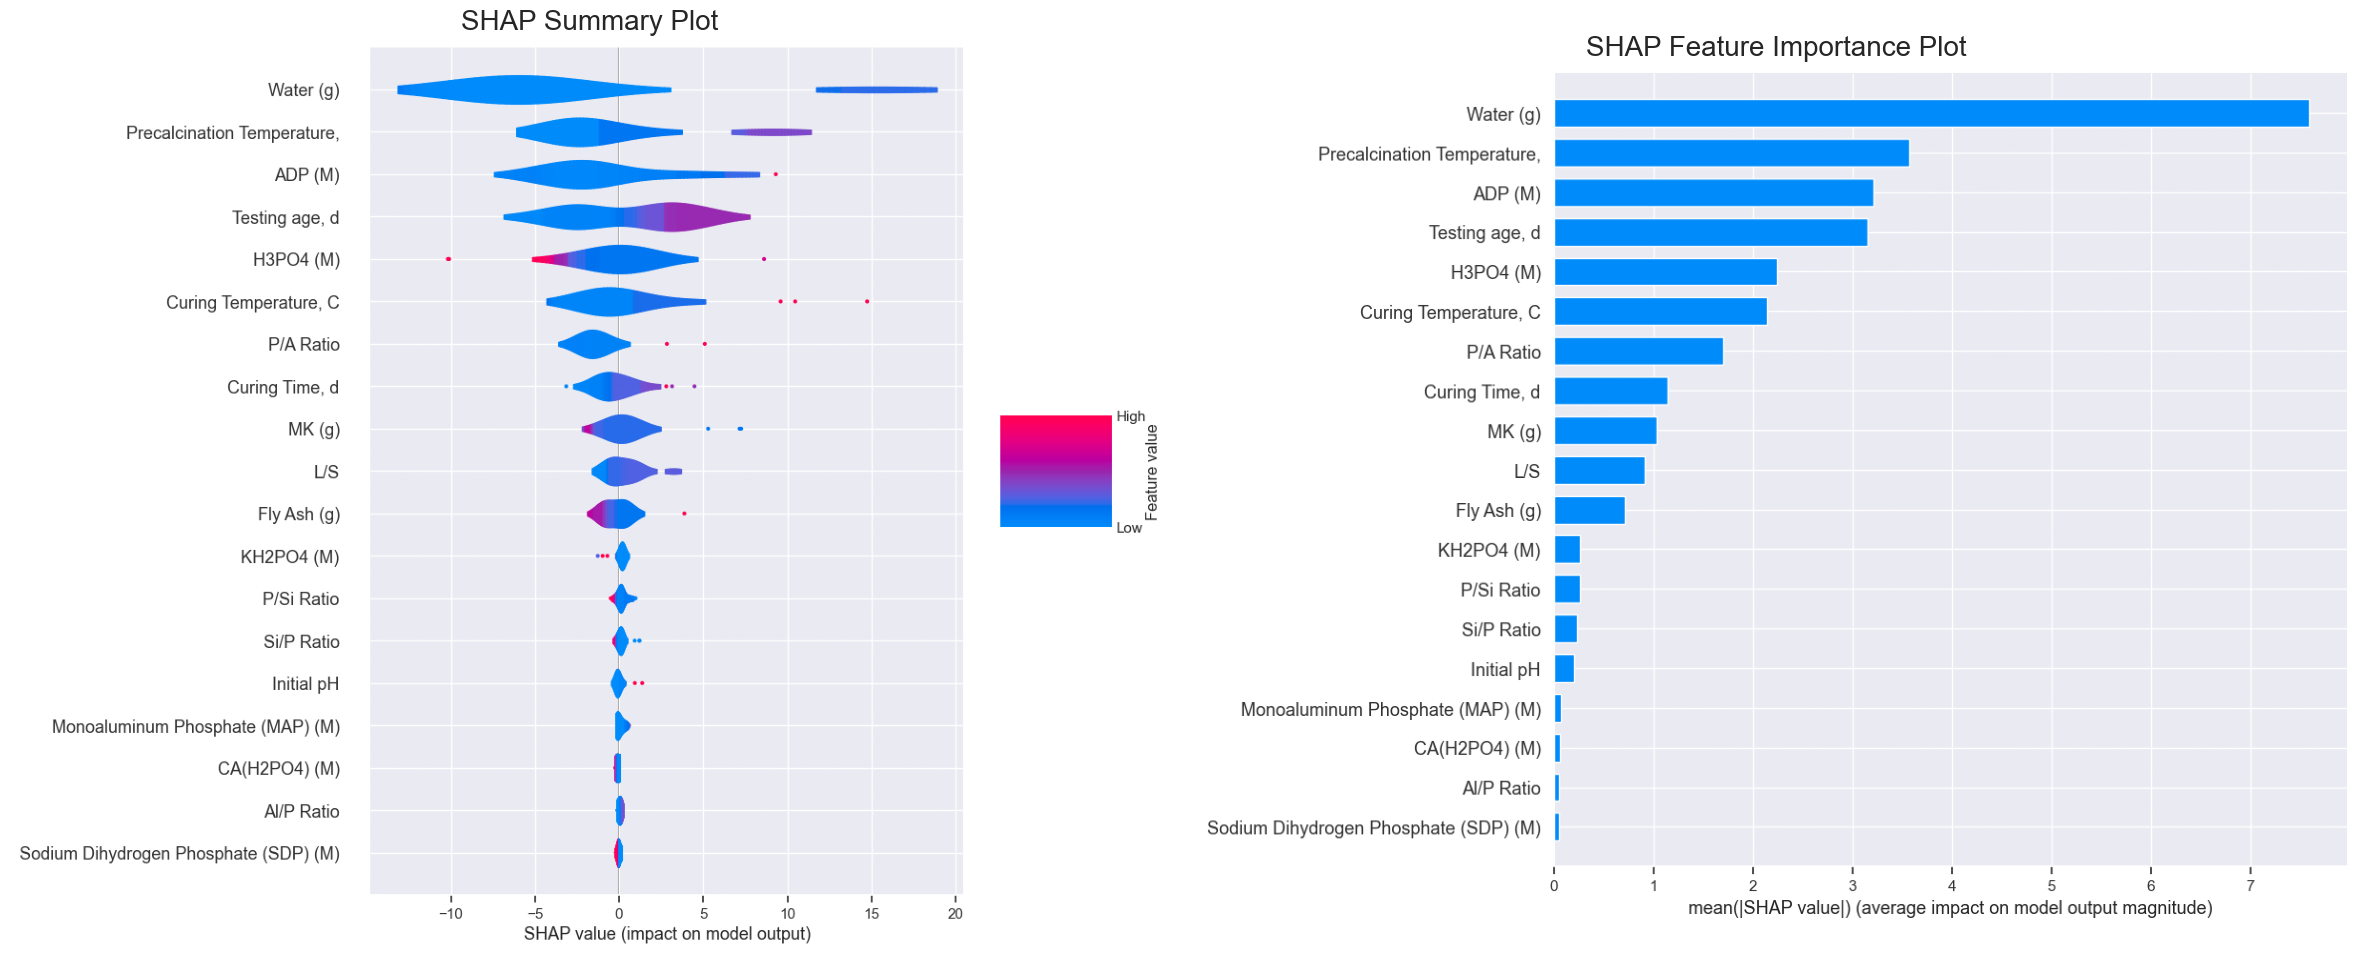

Text(0.5, 0, 'Relative Importance')

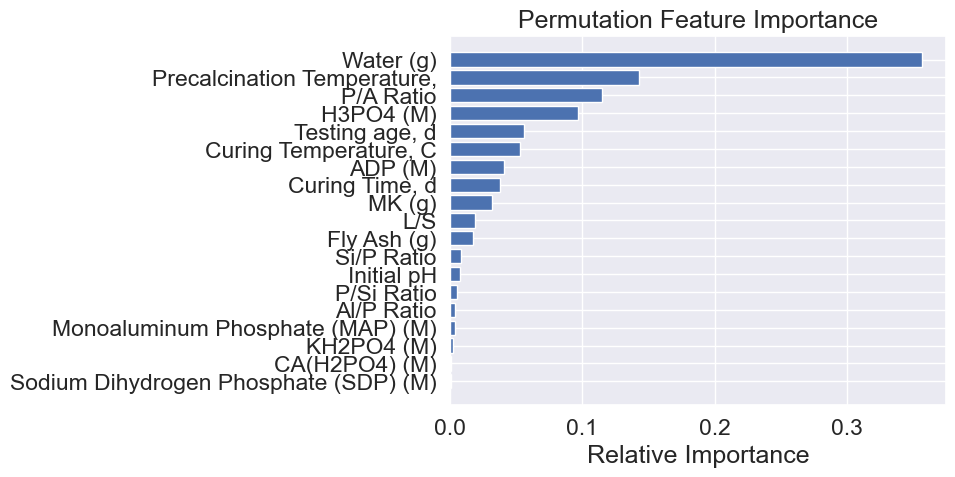

In [23]:
# Train the best model on the full training data
best_model.fit(X_train_scaled, y_train)

# SHAP analysis for the best model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_size=(12, 10), show=False, plot_type='violin')
plt.gcf().axes[-1].set_box_aspect(1)  # To maintain aspect ratio for color bar
plt.savefig('shap_summary_plot.png', bbox_inches='tight')
plt.close()

# SHAP feature importance plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar", plot_size=(12, 10), show=False)
plt.gcf().axes[-1].set_box_aspect(1)  # To maintain aspect ratio for color bar
plt.savefig('shap_feature_importance_plot.png', bbox_inches='tight')
plt.close()

# Combine the saved plots into one figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Load and display the saved plots
img1 = plt.imread('shap_summary_plot.png')
img2 = plt.imread('shap_feature_importance_plot.png')

ax1.imshow(img1)
ax1.axis('off')
ax1.set_title('SHAP Summary Plot', fontsize=20)

ax2.imshow(img2)
ax2.axis('off')
ax2.set_title('SHAP Feature Importance Plot', fontsize=20)

plt.tight_layout()
plt.show()

importances = best_model.feature_importances_
indices = np.argsort(importances)

importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.title('Permutation Feature Importance')
plt.barh(range(X_test_scaled.shape[1]), importances[indices], align='center')
plt.yticks(range(X_test_scaled.shape[1]), [X_test.columns[i] for i in indices])
plt.xlabel('Relative Importance')


In [24]:
# Print performance metrics for the best model on test data
y_pred_best = best_model.predict(X_test_scaled)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mape_best = robust_mape(y_test, y_pred_best)

print("Best Model Evaluation on Test Data:")
print(f"RMSE: {rmse_best:.3f}")
print(f"R-squared: {r2_best:.3f}")
print(f"MAE: {mae_best:.3f}")
print(f"MAPE: {mape_best:.3f}")


Best Model Evaluation on Test Data:
RMSE: 10.365
R-squared: 0.726
MAE: 4.689
MAPE: 31.296


<a id="Local-SHAP-Analysis"></a>
Your local SHAP analysis content goes here.  

In [25]:
# Identify top 5 features from SHAP values
top_features_indices = np.argsort(np.abs(shap_values).mean(0))[-5:]
top_features = [X_test.columns[i] for i in top_features_indices]
#top_features = ['Metakaolin (wt.%)', 'Age', 'H3PO4 concentration (wt%)', 'Aluminum Dihydrogen Phosphate Concentration, %', 'Activation Temperature (°C)', 'Fly Ash (g)']
print("Top 5 features based on SHAP values:", top_features)


Top 5 features based on SHAP values: ['H3PO4 (M)', 'Testing age, d', 'ADP (M)', 'Precalcination Temperature,', 'Water (g)']


Checking scaling and inverse transformation...
Feature: H3PO4 (M)
Original values: [17.19  2.11  0.   17.19 14.  ]
Scaled values: [ 1.43331851 -0.69137238 -0.98866003  1.43331851  0.98386467]
Inverse transformed values: [17.19  2.11  0.   17.19 14.  ]


Feature: Testing age, d
Original values: [28  7 60  7 60]
Scaled values: [ 0.08517413 -0.8333253   1.48479231 -0.8333253   1.48479231]
Inverse transformed values: [28.  7. 60.  7. 60.]


Feature: ADP (M)
Original values: [0.  0.  0.9 0.  0. ]
Scaled values: [-0.52823855 -0.52823855  0.1851651  -0.52823855 -0.52823855]
Inverse transformed values: [0.  0.  0.9 0.  0. ]


Feature: Precalcination Temperature,
Original values: [  0   0   0   0 700]
Scaled values: [-0.732768   -0.732768   -0.732768   -0.732768    1.20348652]
Inverse transformed values: [  0.   0.   0.   0. 700.]


Feature: Water (g)
Original values: [ 15.6  164.84   0.     0.     0.  ]
Scaled values: [-0.17170137  3.14601632 -0.51850113 -0.51850113 -0.51850113]
Inverse transf

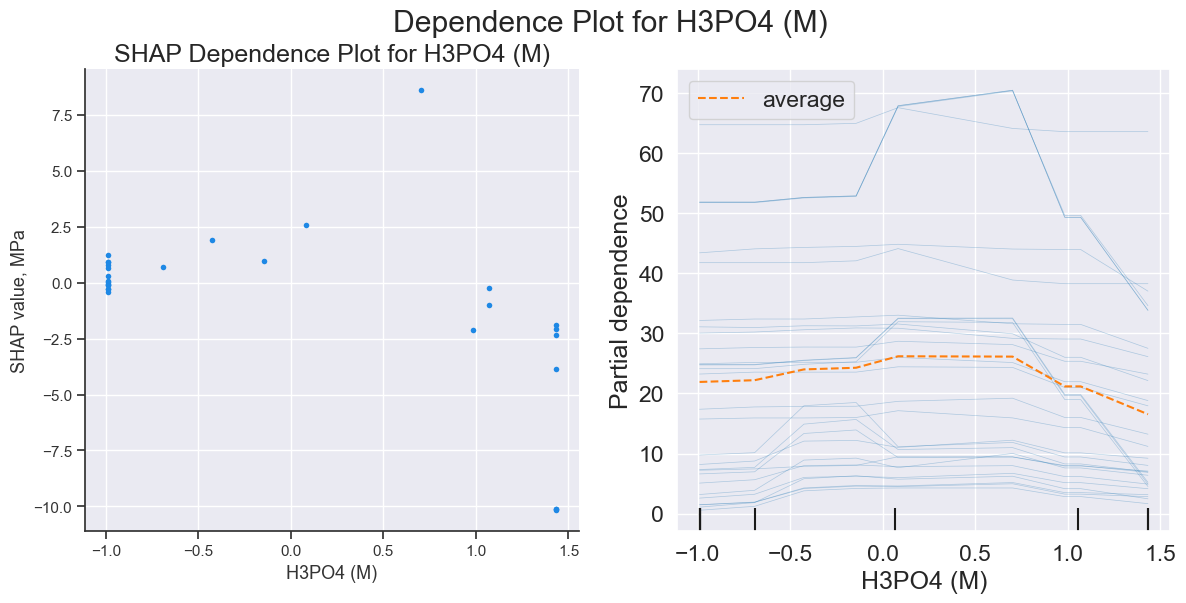

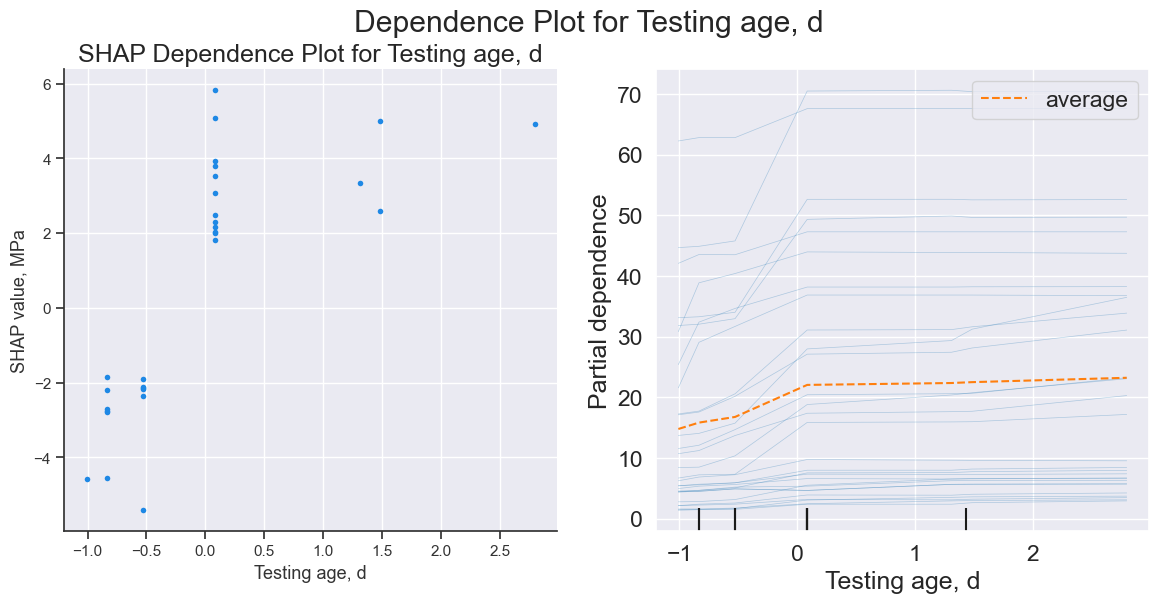

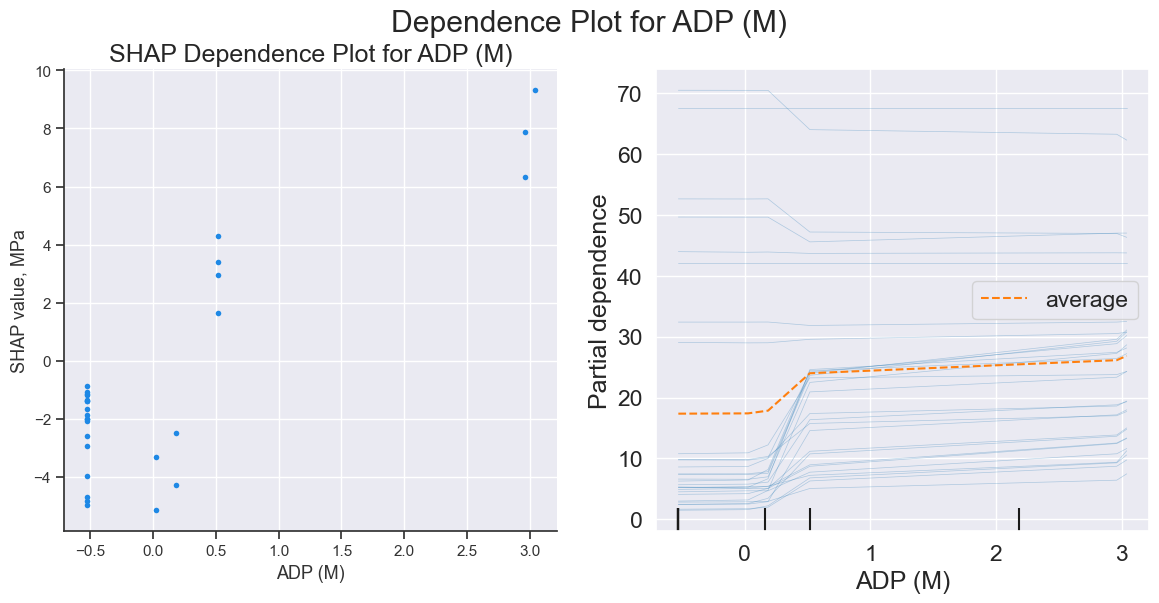

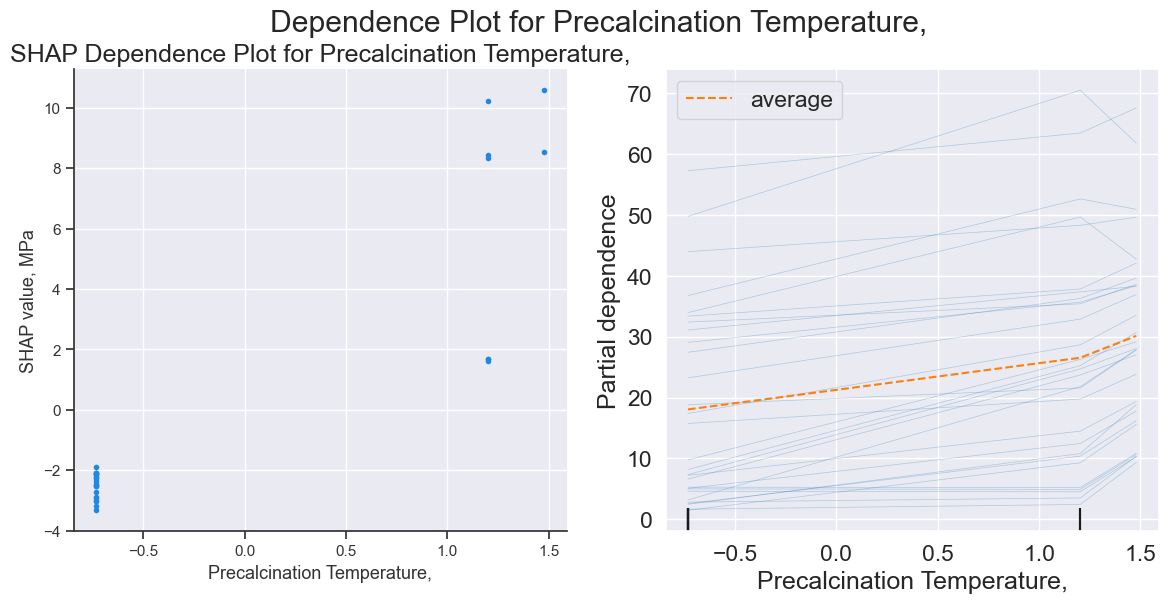

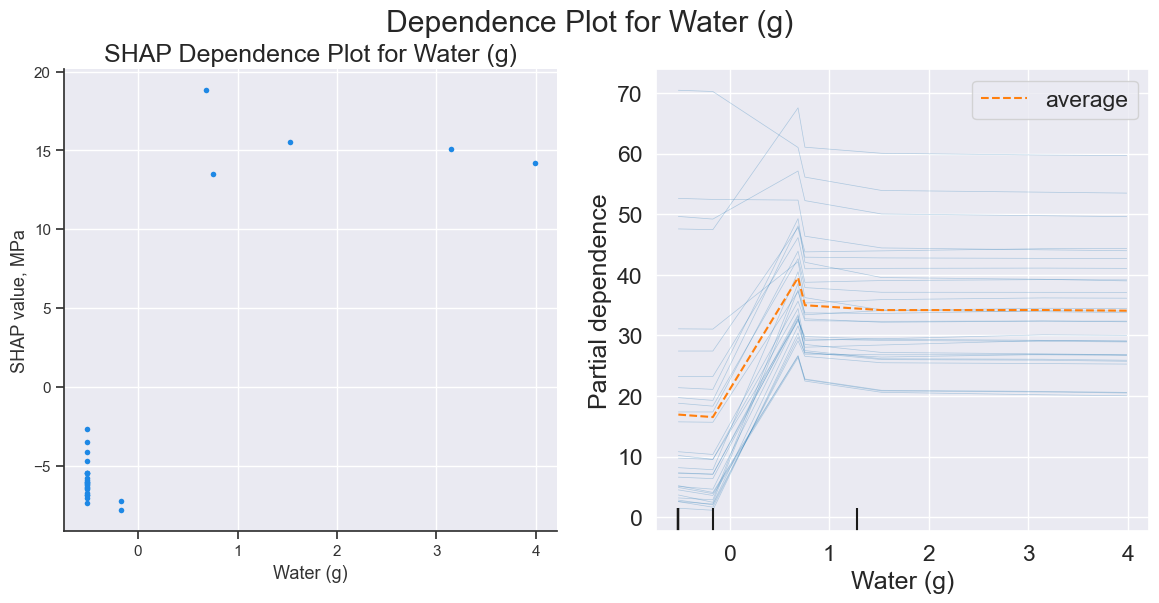

In [26]:
# Function to inverse transform the scaled data for a specific feature
def inverse_transform_feature(scaled_values, feature_index, scaler):
    temp_data = np.zeros((scaled_values.shape[0], len(scaler.mean_)))
    temp_data[:, feature_index] = scaled_values.flatten()
    return scaler.inverse_transform(temp_data)[:, feature_index]

# Check scaling and inverse transformation
print("Checking scaling and inverse transformation...")
for feature in top_features:
    feature_index = X_test.columns.get_loc(feature)
    original_values = X_test[feature].values[:5]  # Take first 5 values for simplicity
    scaled_values = X_test_scaled[:5, feature_index].reshape(-1, 1)
    inverse_transformed_values = inverse_transform_feature(scaled_values, feature_index, scaler)
    
    print(f"Feature: {feature}")
    print(f"Original values: {original_values}")
    print(f"Scaled values: {scaled_values.flatten()}")
    print(f"Inverse transformed values: {inverse_transformed_values}")
    print("\n")

# Create plots
for feature in top_features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # SHAP Dependence Plot
    shap.dependence_plot(feature, shap_values, X_test_scaled, feature_names=X_test.columns, interaction_index=None, show=False, ax=ax1)
    
    # Partial Dependence Plot
    display = PartialDependenceDisplay.from_estimator(best_model, X_test_scaled, [feature], feature_names=X_test.columns, kind='both', grid_resolution=50, ax=ax2)
    
    ax1.set_title(f'SHAP Dependence Plot for {feature}')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('SHAP value, MPa')

    # Set the title and adjust the plot
    fig.suptitle(f'Dependence Plot for {feature}')
    
    # Adjust x-axis to use original feature values for PDP
    feature_index = X_test.columns.get_loc(feature)
    ticks_scaled = np.linspace(X_test_scaled[:, feature_index].min(), X_test_scaled[:, feature_index].max(), num=5).reshape(-1, 1)
    ticks_original = inverse_transform_feature(ticks_scaled, feature_index, scaler)
    
    ax2.set_xticks(ticks_scaled.flatten())
    ax2.set_xticklabels([f'{val:.2f}' for val in ticks_original])
    
    plt.show()

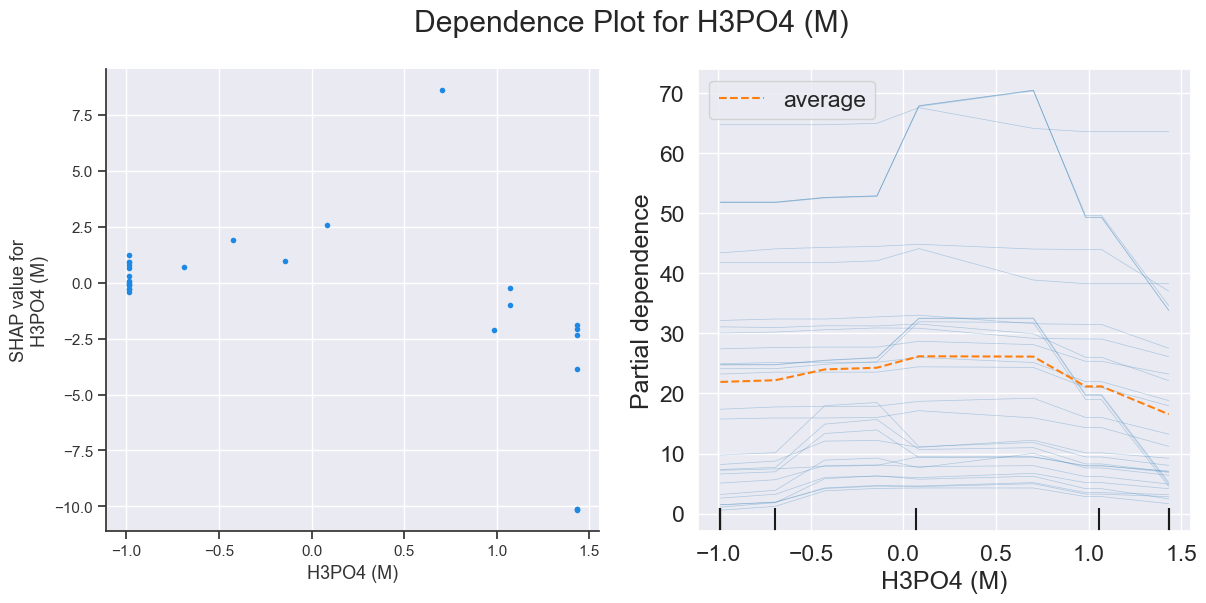

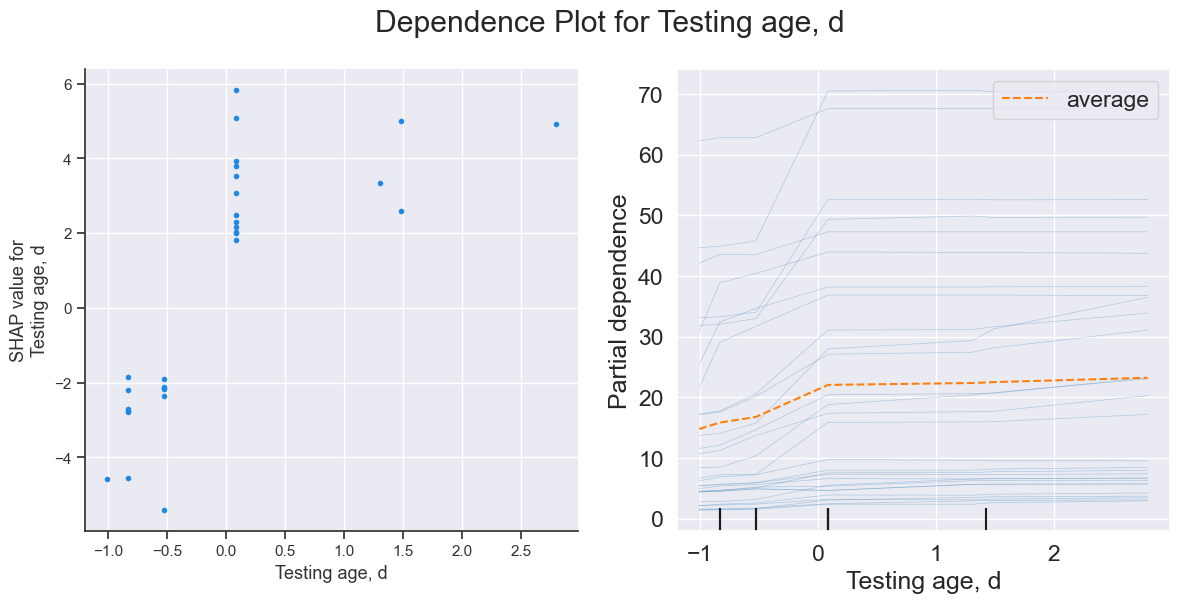

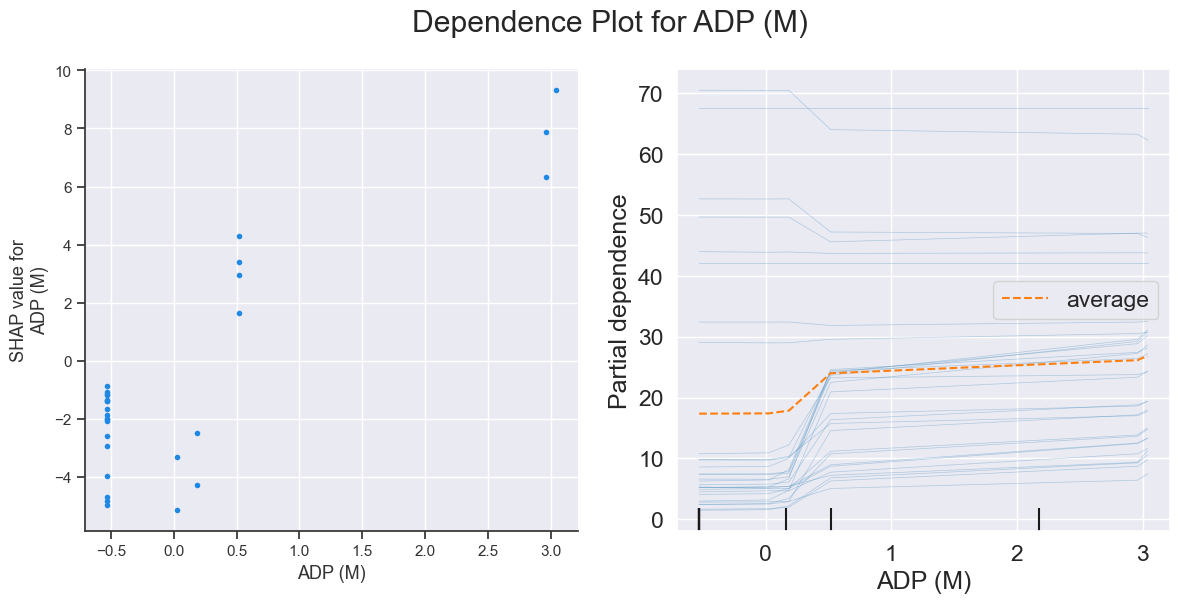

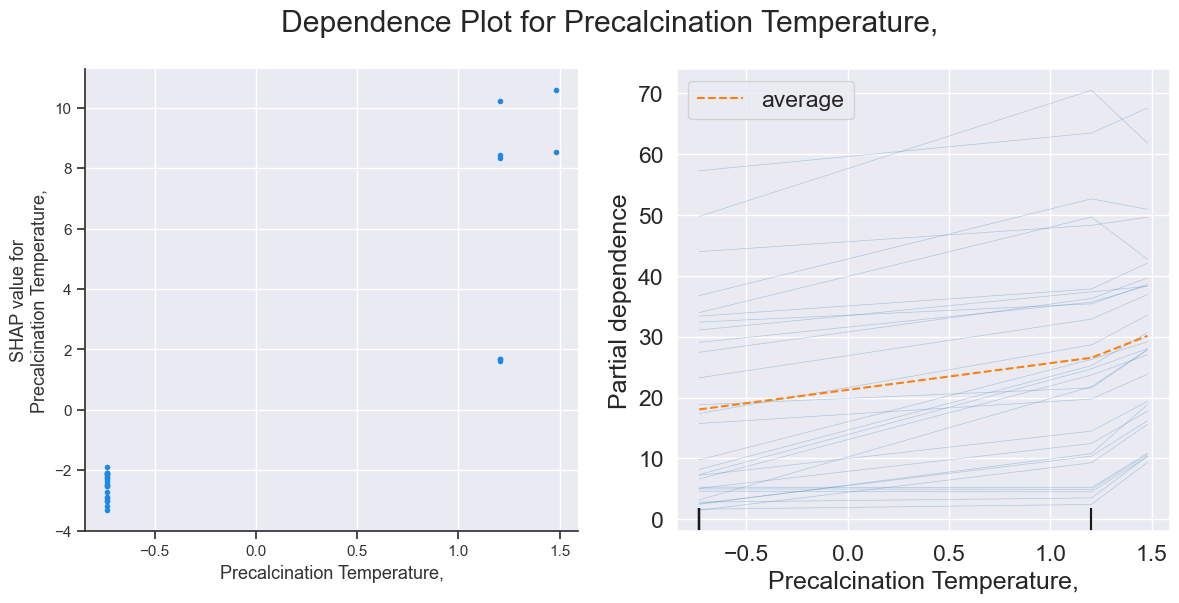

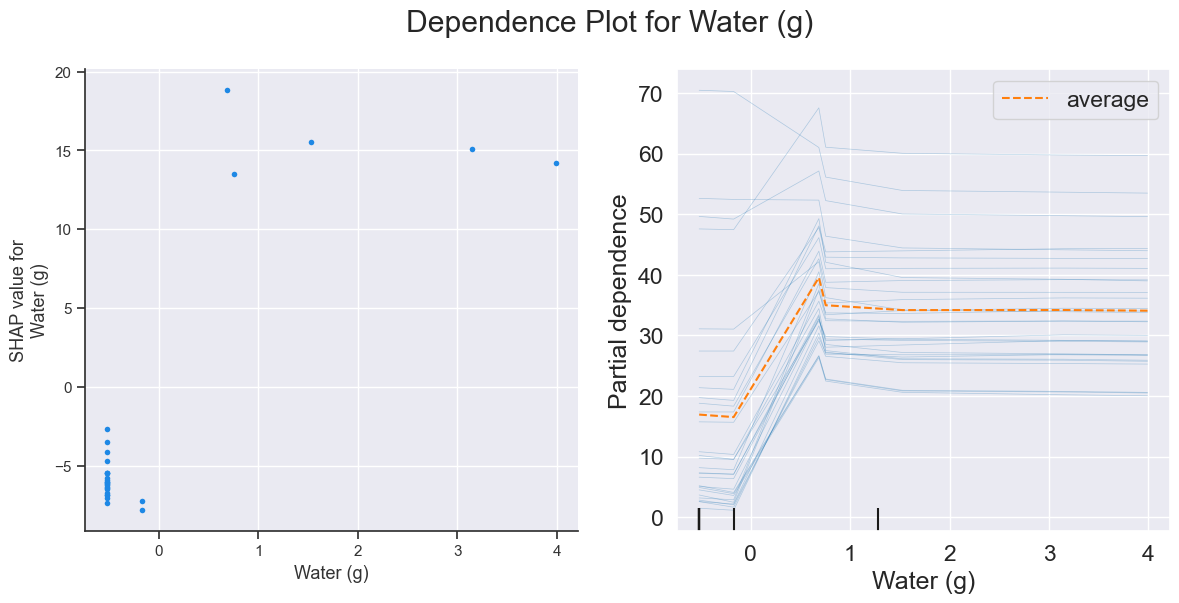

In [32]:
### ORIGINAL DATASET - X instead of X_SCALED 
def plot_with_original_values(feature, shap_values, X, X_scaled, scaler, model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # SHAP Dependence Plot
    shap.dependence_plot(feature, shap_values, X_scaled, feature_names=X.columns, interaction_index=None, show=False, ax=ax1)
    
    # Partial Dependence Plot
    # Create the partial dependence plot using the original (inverse-transformed) features
    feature_index = X.columns.get_loc(feature)
    disp = PartialDependenceDisplay.from_estimator(best_model, X_scaled, [feature_index], feature_names=X.columns, kind='both', ax=ax2)
    
    # Set the title and adjust the plot
    fig.suptitle(f'Dependence Plot for {feature}')
    
    # Adjust x-axis to use original feature values for PDP
    #ticks_original = np.linspace(X[feature].min(), X[feature].max(), num=5)
    # Instead of transforming ticks, we directly set the x-ticks to original values
    #ax2.set_xticks(ticks_original)
    #ax2.set_xticklabels([f'{val:.2f}' for val in ticks_original])
    
    plt.show()

# Create plots
for feature in top_features:
    plot_with_original_values(feature, shap_values, X_test, X_test_scaled, scaler, best_model)

Original ticks: [ 0.     3.438  6.876 10.314 13.752 17.19 ]
Scaled ticks: [-0.98866003 -0.50426432 -0.01986861  0.4645271   0.9489228   1.43331851]


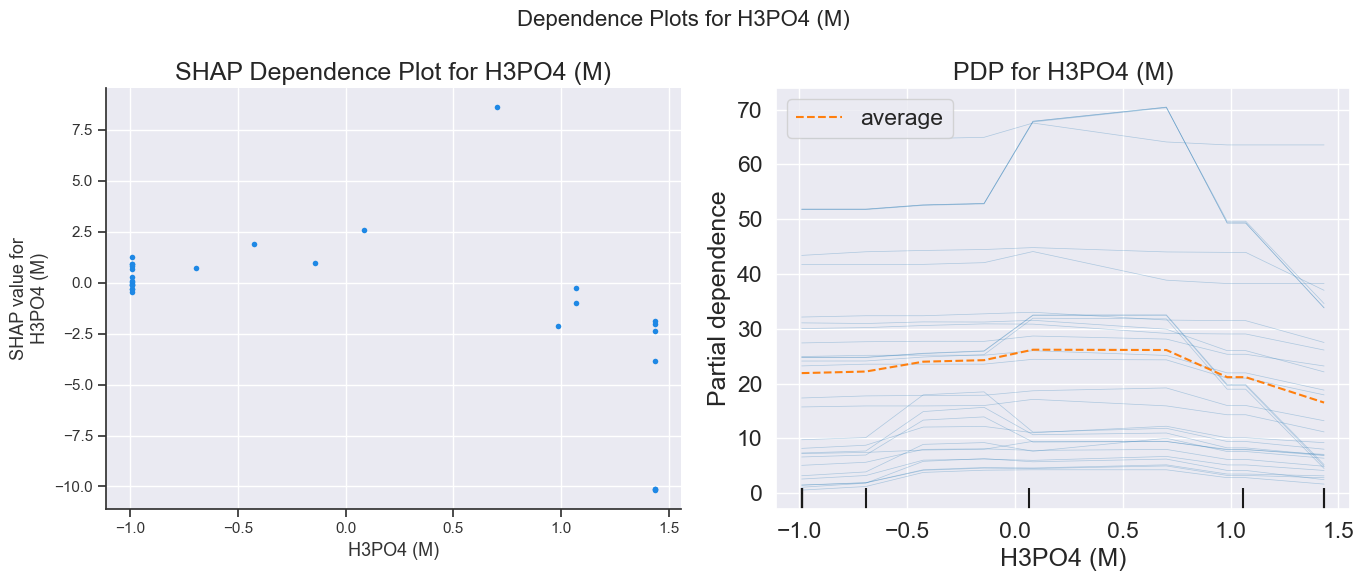

Original ticks: [ 3.  20.4 37.8 55.2 72.6 90. ]
Scaled ticks: [-1.00827757 -0.24723518  0.5138072   1.27484958  2.03589197  2.79693435]


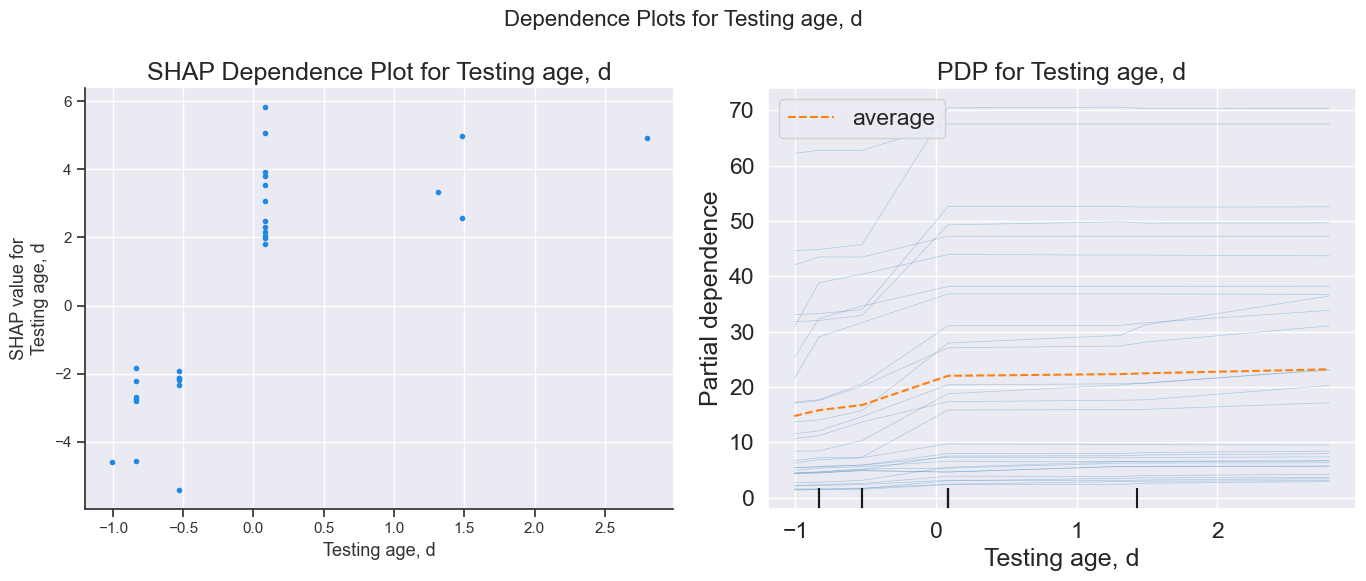

Original ticks: [0.  0.9 1.8 2.7 3.6 4.5]
Scaled ticks: [-0.52823855  0.1851651   0.89856875  1.6119724   2.32537605  3.0387797 ]


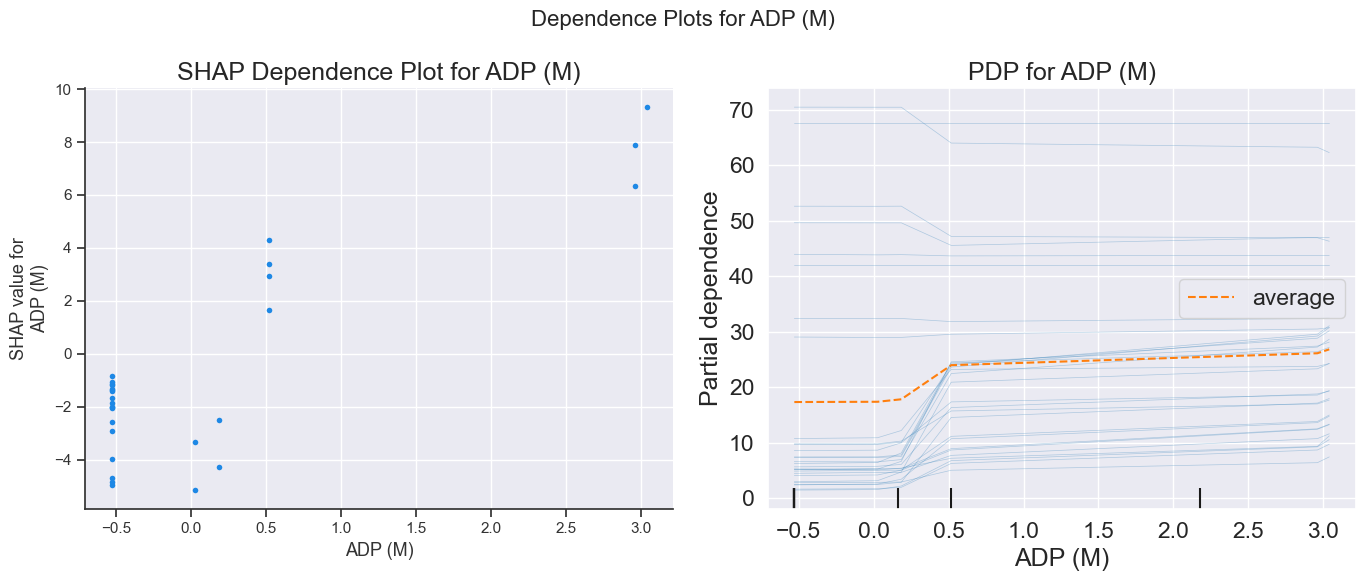

Original ticks: [  0. 160. 320. 480. 640. 800.]
Scaled ticks: [-0.732768   -0.29019554  0.15237692  0.59494938  1.03752185  1.48009431]


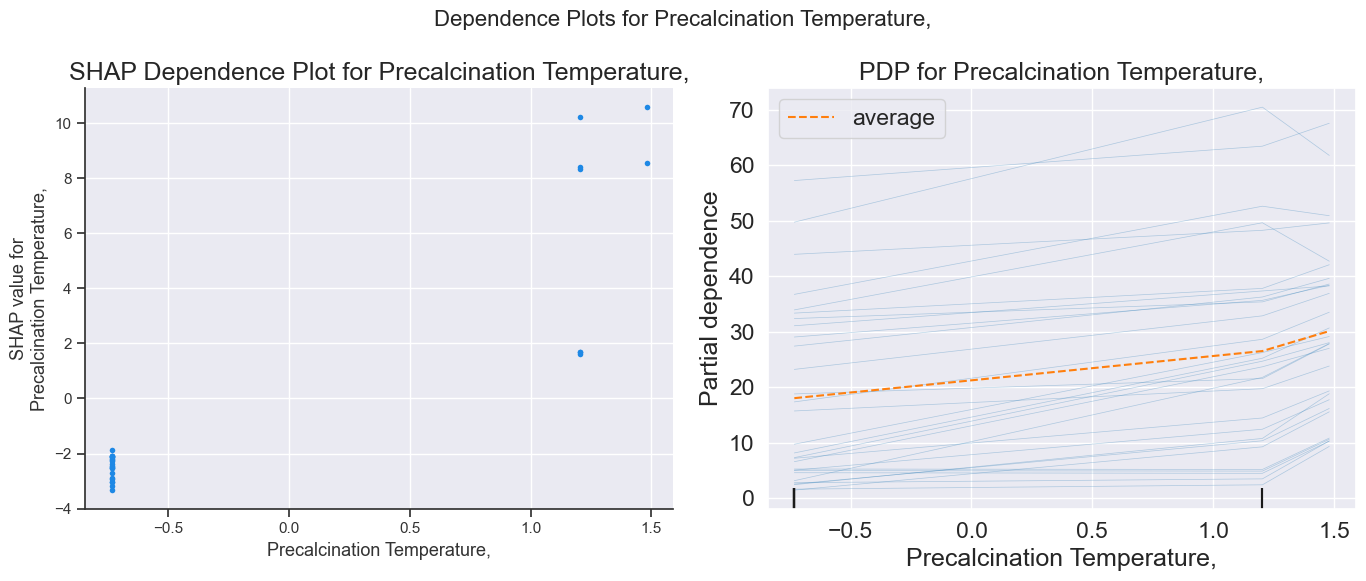

Original ticks: [  0.     40.562  81.124 121.686 162.248 202.81 ]
Scaled ticks: [-0.51850113  0.3832227   1.28494654  2.18667037  3.08839421  3.99011804]


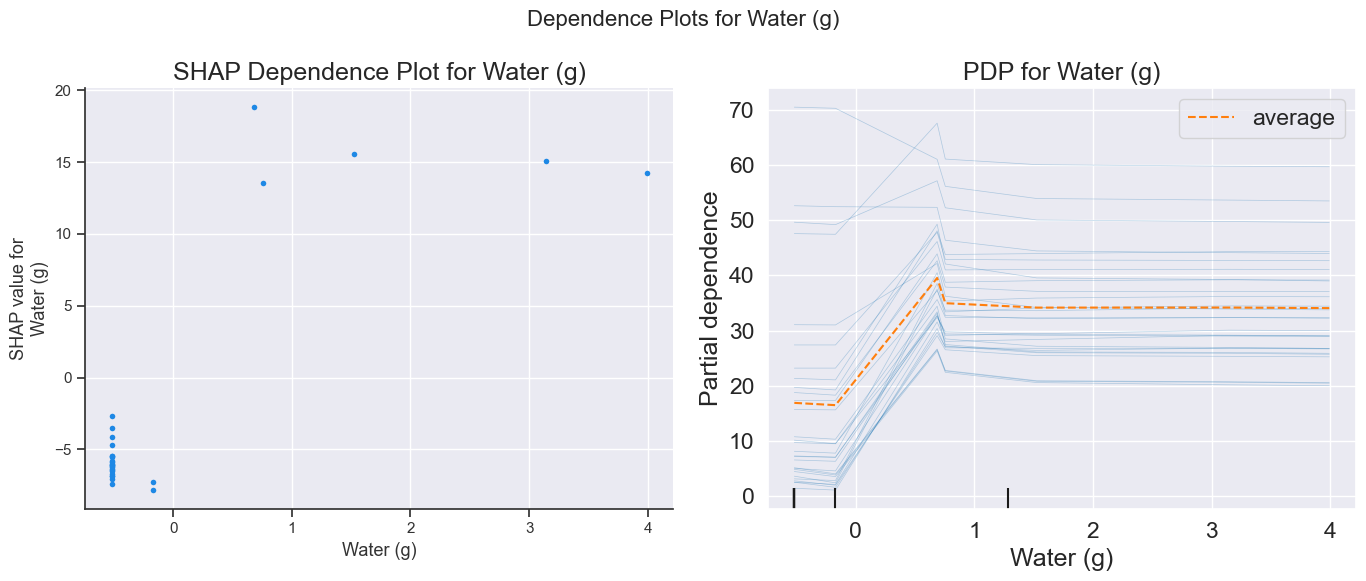

In [47]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Function to create SHAP and PDP plots with original feature values
def plot_with_original_values(feature, shap_values, X, X_scaled, scaler, model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # SHAP Dependence Plot
    shap.dependence_plot(feature, shap_values, X_scaled, feature_names=X.columns, interaction_index=None, show=False, ax=ax1)
    
    # Partial Dependence Plot
    feature_index = X.columns.get_loc(feature)
    
    # Generate original tick values
    feature_values = X[feature].values
    min_val, max_val = feature_values.min(), feature_values.max()
    original_ticks = np.linspace(min_val, max_val, num=6)  # Adjust number of ticks as needed
    print(f"Original ticks: {original_ticks}")

    # Scale these ticks using the StandardScaler
    scaled_ticks = (original_ticks - scaler.mean_[feature_index]) / scaler.scale_[feature_index]
    print(f"Scaled ticks: {scaled_ticks}")
    
    # Create the partial dependence plot using the scaled ticks
    disp = PartialDependenceDisplay.from_estimator(model, X_scaled, [feature_index], feature_names=X.columns, kind='both', ax=ax2)
    
    # Set the original feature values as xticks
    ax2.set_xticks(scaled_ticks)
    ax2.set_xticklabels([f'{val:.2f}' for val in original_ticks])
    
    # Set titles
    ax1.set_title(f'SHAP Dependence Plot for {feature}')
    ax2.set_title(f'PDP for {feature}')
    
    fig.suptitle(f'Dependence Plots for {feature}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Example usage
# Assuming `top_features` is a list of feature names and `shap_values`, `X_test`, `X_test_scaled`, `scaler`, and `best_model` are defined
for feature in top_features:
    plot_with_original_values(feature, shap_values, X_test, X_test_scaled, scaler, best_model)


Original ticks: [ 0.     3.438  6.876 10.314 13.752 17.19 ]
Scaled ticks: [-0.98866003 -0.50426432 -0.01986861  0.4645271   0.9489228   1.43331851]


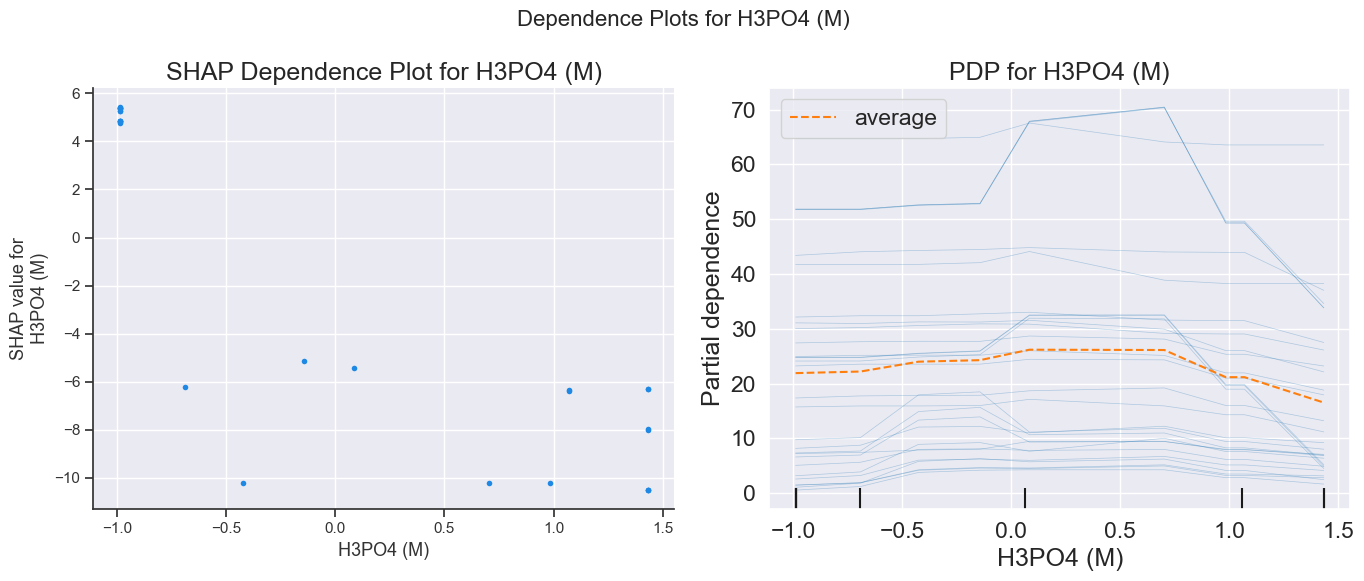

Original ticks: [ 3.  20.4 37.8 55.2 72.6 90. ]
Scaled ticks: [-1.00827757 -0.24723518  0.5138072   1.27484958  2.03589197  2.79693435]


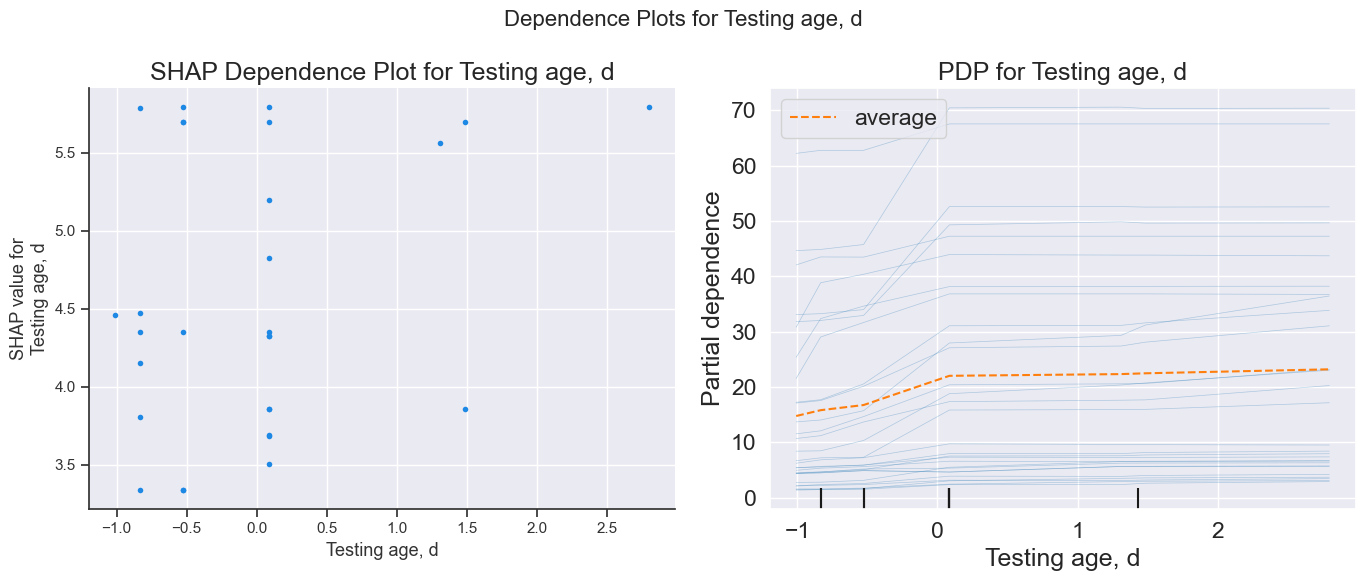

Original ticks: [0.  0.9 1.8 2.7 3.6 4.5]
Scaled ticks: [-0.52823855  0.1851651   0.89856875  1.6119724   2.32537605  3.0387797 ]


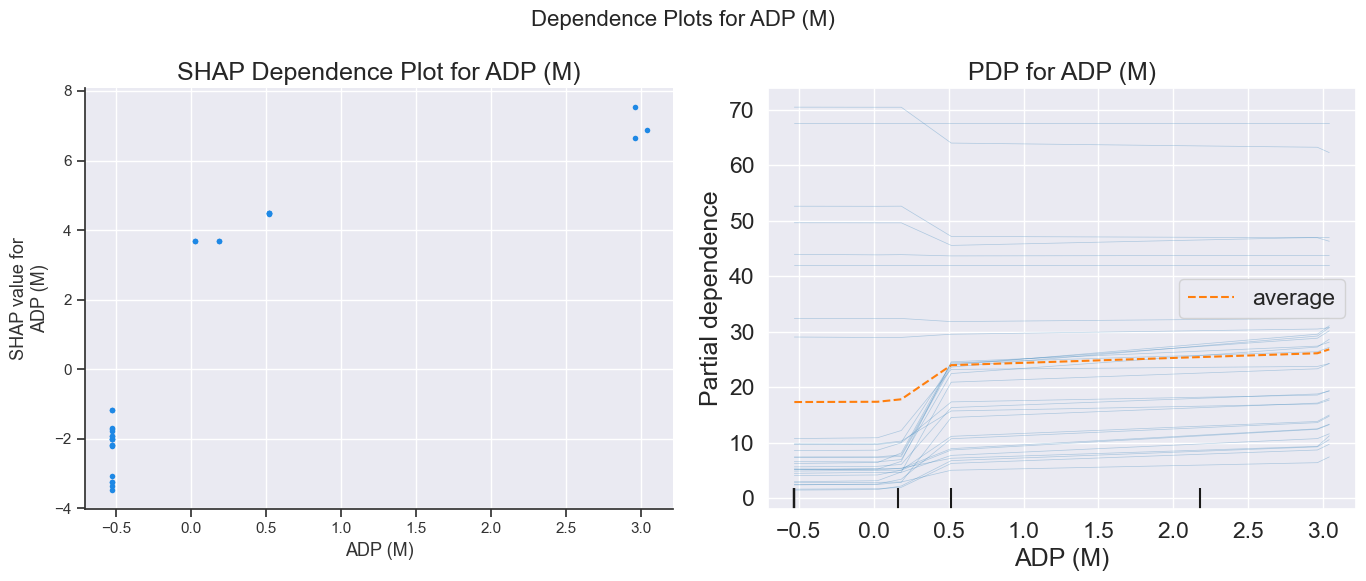

Original ticks: [  0. 160. 320. 480. 640. 800.]
Scaled ticks: [-0.732768   -0.29019554  0.15237692  0.59494938  1.03752185  1.48009431]


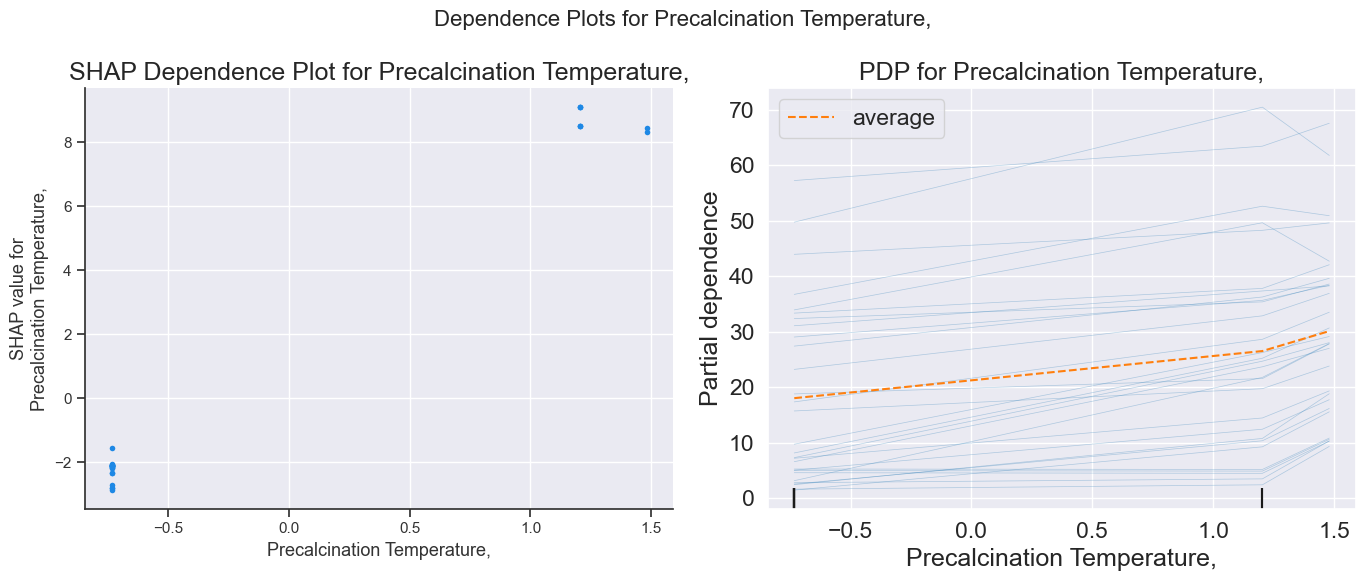

Original ticks: [  0.     40.562  81.124 121.686 162.248 202.81 ]
Scaled ticks: [-0.51850113  0.3832227   1.28494654  2.18667037  3.08839421  3.99011804]


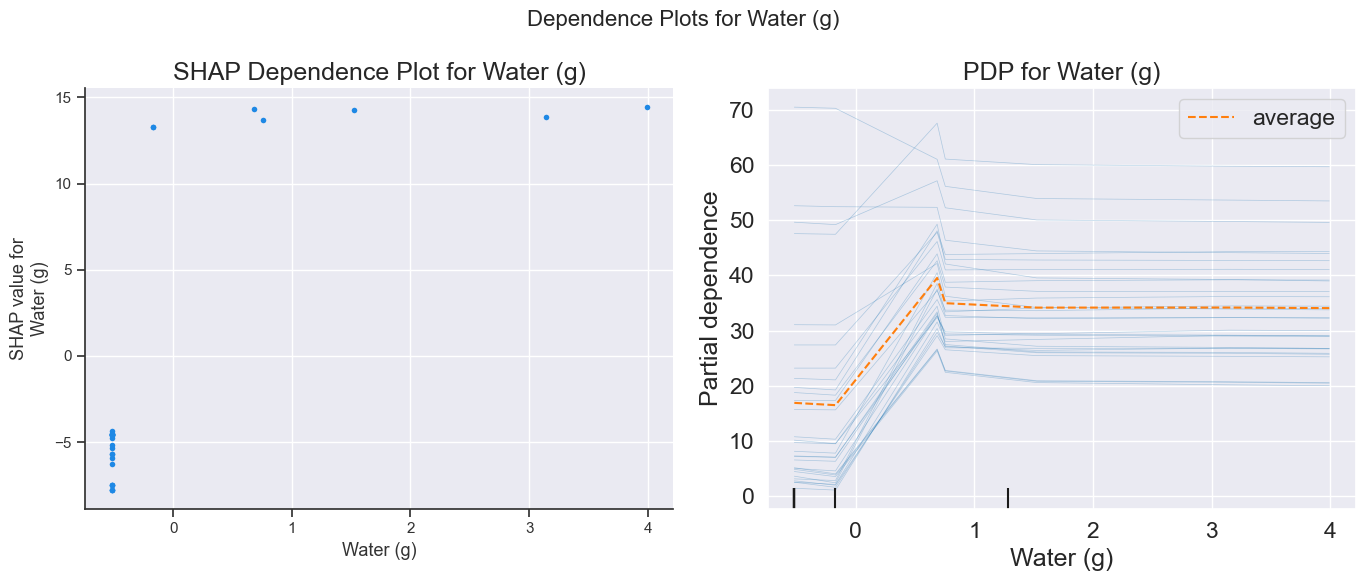

In [57]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Function to create SHAP and PDP plots with original feature values
def plot_with_original_values(feature, shap_values, X, X_scaled, scaler, model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # SHAP Dependence Plot
    shap.dependence_plot(feature, shap_values, X_scaled, feature_names=X.columns, interaction_index=None, show=False, ax=ax1)
    
    # Partial Dependence Plot
    feature_index = X.columns.get_loc(feature)
    
    # Generate original tick values
    feature_values = X[feature].values
    min_val, max_val = feature_values.min(), feature_values.max()
    original_ticks = np.linspace(min_val, max_val, num=6)  # Adjust number of ticks as needed
    print(f"Original ticks: {original_ticks}")

    # Scale these ticks using the StandardScaler
    scaled_ticks = (original_ticks - scaler.mean_[feature_index]) / scaler.scale_[feature_index]
    print(f"Scaled ticks: {scaled_ticks}")
    
    # Create the partial dependence plot using the scaled ticks
    disp = PartialDependenceDisplay.from_estimator(model, X_scaled, [feature_index], feature_names=X.columns, kind='both', ax=ax2)
    
    # Explicitly set the tick locations and labels
    ax2.set_xticks(scaled_ticks)
    ax2.set_xticklabels([f'{val:.2f}' for val in original_ticks])
    
    # Set titles
    ax1.set_title(f'SHAP Dependence Plot for {feature}')
    ax2.set_title(f'PDP for {feature}')
    
    fig.suptitle(f'Dependence Plots for {feature}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Example usage
# Assuming `top_features` is a list of feature names and `shap_values`, `X_test`, `X_test_scaled`, `scaler`, and `best_model` are defined
for feature in top_features:
    plot_with_original_values(feature, shap_values, X_test, X_test_scaled, scaler, best_model)


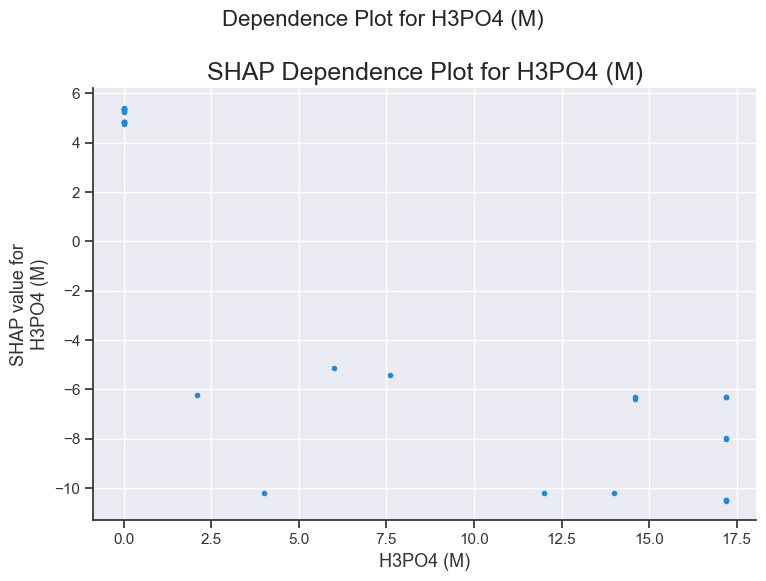

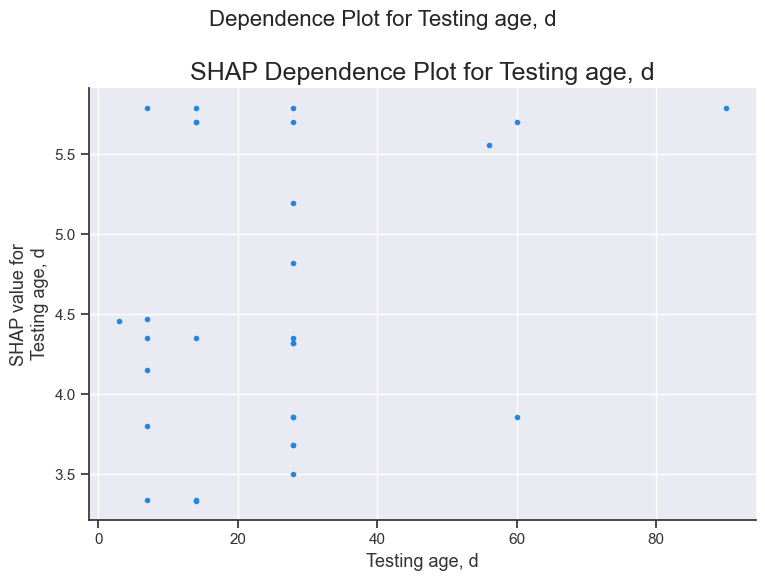

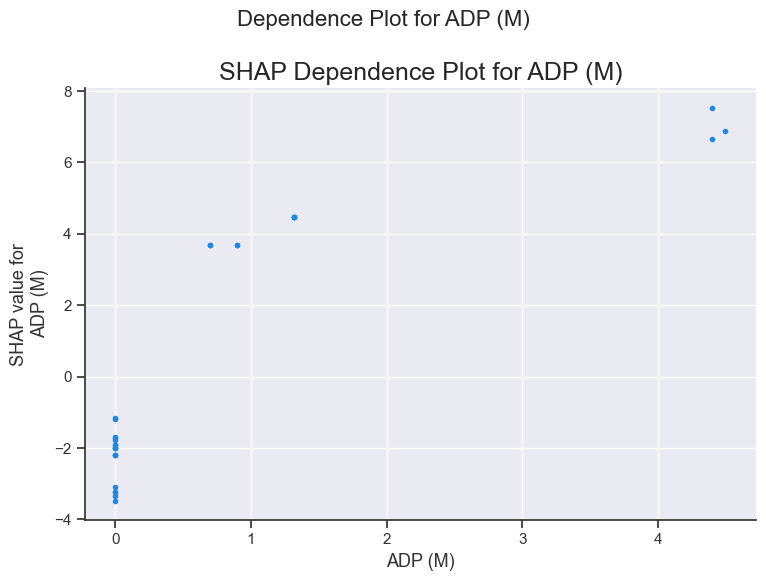

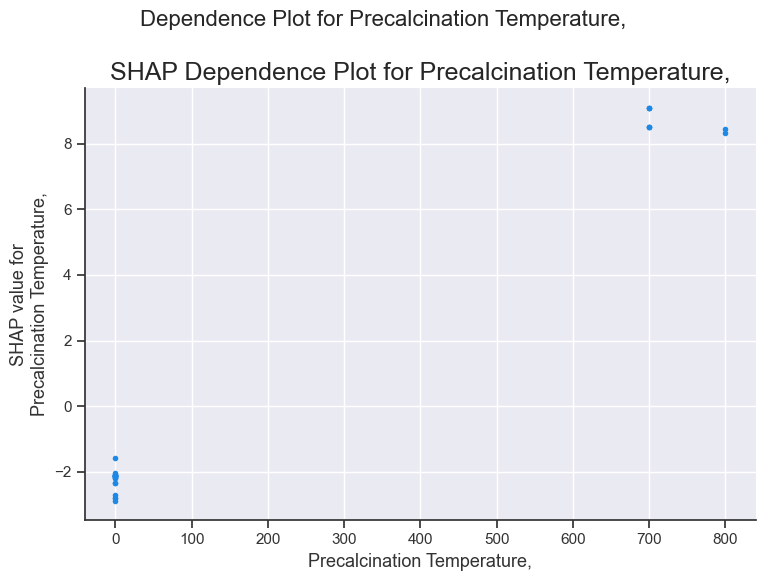

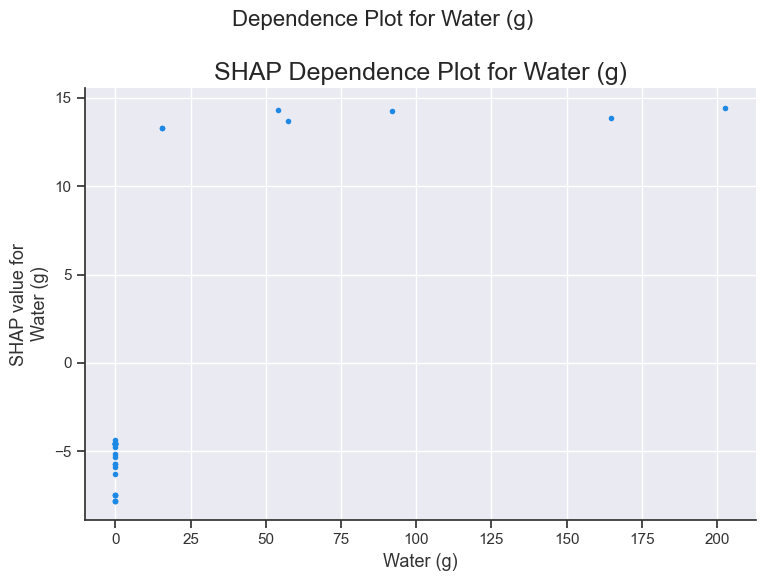

In [55]:
import shap
import matplotlib.pyplot as plt

# Function to plot SHAP dependence plot with original feature values
def plot_shap_dependence(feature, shap_values, X):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # SHAP Dependence Plot
    shap.dependence_plot(feature, shap_values, X, feature_names=X.columns, interaction_index=None, show=False, ax=ax)
    
    # Set titles
    ax.set_title(f'SHAP Dependence Plot for {feature}')
    
    fig.suptitle(f'Dependence Plot for {feature}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Calculate SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Example usage
# Assuming `top_features` is a list of feature names and `X_test` is defined
for feature in top_features:
    plot_shap_dependence(feature, shap_values, X_test)


<a id="Conclusion"></a>
# Conclusion

# References